# Данный файл содержит кодовую часть финального проекта по Научной студии (Поиск экспортных рынков).

План проекта:

- Подсчет метрик (HHI, RCA, ECI)

- Гравитационная модель

- Временные ряды

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL, MSTL, seasonal_decompose
import comtradeapicall
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import io
import warnings

np.random.seed(42)
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Списки перевода кодов стран

In [2]:
country_to_iso3 = {
    "Cote d'Ivoire": "CIV",
    "Egypt": "EGY",
    "Ethiopia": "ETH",
    "Ghana": "GHA",
    "Kenya": "KEN",
    "Morocco": "MAR",
    "Madagascar": "MDG",
    "Mozambique": "MOZ",
    "Mauritania": "MRT",
    "Mauritius": "MUS",
    "Namibia": "NAM",
    "Niger": "NER",
    "Togo": "TGO",
    "Tunisia": "TUN",
    "Tanzania": "TZA",
    "South Africa": "ZAF",
    "Zambia": "ZMB",
    "Zimbabwe": "ZWE",
    "United Arab Emirates": "ARE",
    "China": "CHN",
    "Hong Kong": "HKG",
    "Indonesia": "IDN",
    "India": "IND",
    "Iran": "IRN",
    "Israel": "ISR",
    "Jordan": "JOR",
    "Japan": "JPN",
    "Cambodia": "KHM",
    "South Korea": "KOR",
    "Laos": "LAO",
    "Lebanon": "LBN",
    "Sri Lanka": "LKA",
    "Malaysia": "MYS",
    "Philippines": "PHL",
    "Saudi Arabia": "SAU",
    "Singapore": "SGP",
    "Thailand": "THA",
    "Turkey": "TUR",
    "Chinese Taipei": "TWN",  
    "Uzbekistan": "UZB",
    "Vietnam": "VNM",
    "Austria": "AUT",
    "Belgium": "BEL",
    "Bulgaria": "BGR",
    "Belarus": "BLR",
    "Switzerland": "CHE",
    "Czechia": "CZE",
    "Germany": "DEU",
    "Denmark": "DNK",
    "Spain": "ESP",
    "Estonia": "EST",
    "Finland": "FIN",
    "France": "FRA",
    "United Kingdom": "GBR",
    "Greece": "GRC",
    "Croatia": "HRV",
    "Hungary": "HUN",
    "Ireland": "IRL",
    "Italy": "ITA",
    "Lithuania": "LTU",
    "Luxembourg": "LUX",
    "Latvia": "LVA",
    "Malta": "MLT",
    "Netherlands": "NLD",
    "Norway": "NOR",
    "Poland": "POL",
    "Portugal": "PRT",
    "Romania": "ROU",
    "Russia": "RUS",
    "Serbia": "SRB",
    "Slovakia": "SVK",
    "Slovenia": "SVN",
    "Sweden": "SWE",
    "Ukraine": "UKR",
    "Canada": "CAN",
    "Costa Rica": "CRI",
    "Dominican Republic": "DOM",
    "Guatemala": "GTM",
    "Honduras": "HND",
    "Mexico": "MEX",
    "Nicaragua": "NIC",
    "Panama": "PAN",
    "El Salvador": "SLV",
    "Trinidad and Tobago": "TTO",
    "United States": "USA",
    "Australia": "AUS",
    "New Zealand": "NZL",
    "Argentina": "ARG",
    "Brazil": "BRA",
    "Chile": "CHL",
    "Colombia": "COL",
    "Ecuador": "ECU",
    "Peru": "PER",
    "Angola": "AGO",
    "Burundi": "BDI",
    "Republic of the Congo": "COG",
    "Malawi": "MWI",
    "Nigeria": "NGA",
    "Senegal": "SEN",
    "Eswatini": "SWZ",
    "Uganda": "UGA",
    "Cyprus": "CYP",
    "Kyrgyzstan": "KGZ",
    "Pakistan": "PAK",
    "Iceland": "ISL",
    "Bolivia": "BOL",
    "Guyana": "GUY",
    "Botswana": "BWA",
    "Azerbaijan": "AZE",
    "Georgia": "GEO",
    "Qatar": "QAT",
    "Barbados": "BRB",
    "Paraguay": "PRY",
    "Uruguay": "URY",
    "Gambia": "GMB",
    "Brunei": "BRN",
    "Oman": "OMN",
    "Andorra": "AND",
    "Bermuda": "BMU",
    "Cuba": "CUB",
    "Benin": "BEN",
    "Burkina Faso": "BFA",
    "Gabon": "GAB",
    "Kazakhstan": "KAZ",
    "Burma": "MMR", 
    "Fiji": "FJI",
    "Democratic Republic of the Congo": "COD",
    "Eritrea": "ERI",
    "Papua New Guinea": "PNG",
    "New Caledonia": "NCL"
}

In [3]:
iso3_to_ru = {
    'ABW': 'Аруба', 'AFG': 'Афганистан', 'AGO': 'Ангола', 'AIA': 'Ангилья', 
    'ALB': 'Албания', 'AND': 'Андорра', 'ANT': 'Нидерландские Антильские острова', 
    'ARE': 'ОАЭ', 'ARG': 'Аргентина', 'ARM': 'Армения', 'ASM': 'Американское Самоа', 
    'ATG': 'Антигуа и Барбуда', 'AUS': 'Австралия', 'AUT': 'Австрия', 'AZE': 'Азербайджан', 
    'BDI': 'Бурунди', 'BEL': 'Бельгия', 'BEN': 'Бенин', 'BES': 'Бонэйр, Синт-Эстатиус и Саба', 
    'BFA': 'Буркина-Фасо', 'BGD': 'Бангладеш', 'BGR': 'Болгария', 'BHR': 'Бахрейн', 
    'BHS': 'Багамские Острова', 'BIH': 'Босния и Герцеговина', 'BLR': 'Беларусь', 
    'BLZ': 'Белиз', 'BMU': 'Бермудские острова', 'BOL': 'Боливия', 'BRA': 'Бразилия', 
    'BRB': 'Барбадос', 'BRN': 'Бруней', 'BTN': 'Бутан', 'BWA': 'Ботсвана', 
    'CAF': 'ЦАР', 'CAN': 'Канада', 'CCK': 'Кокосовые острова', 'CHE': 'Швейцария', 
    'CHL': 'Чили', 'CHN': 'Китай', 'CIV': "Кот-д'Ивуар", 'CMR': 'Камерун', 
    'COD': 'ДР Конго', 'COG': 'Республика Конго', 'COK': 'Острова Кука', 
    'COL': 'Колумбия', 'COM': 'Коморские Острова', 'CPV': 'Кабо-Верде', 
    'CRI': 'Коста-Рика', 'CUB': 'Куба', 'CUW': 'Кюрасао', 'CXR': 'Остров Рождества', 
    'CYM': 'Каймановы острова', 'CYP': 'Кипр', 'CZE': 'Чехия', 'DEU': 'Германия', 
    'DJI': 'Джибути', 'DMA': 'Доминика', 'DNK': 'Дания', 'DOM': 'Доминиканская Республика', 
    'DZA': 'Алжир', 'ECU': 'Эквадор', 'EGY': 'Египет', 'ERI': 'Эритрея', 
    'ESP': 'Испания', 'EST': 'Эстония', 'ETH': 'Эфиопия', 'FIN': 'Финляндия', 
    'FJI': 'Фиджи', 'FLK': 'Фолклендские острова', 'FRA': 'Франция', 
    'FSM': 'Микронезия', 'GAB': 'Габон', 'GBR': 'Великобритания', 'GEO': 'Грузия', 
    'GHA': 'Гана', 'GIB': 'Гибралтар', 'GIN': 'Гвинея', 'GMB': 'Гамбия', 
    'GNB': 'Гвинея-Бисау', 'GNQ': 'Экваториальная Гвинея', 'GRC': 'Греция', 
    'GRD': 'Гренада', 'GRL': 'Гренландия', 'GTM': 'Гватемала', 'GUM': 'Гуам', 
    'GUY': 'Гайана', 'HKG': 'Гонконг', 'HND': 'Гондурас', 'HRV': 'Хорватия', 
    'HTI': 'Гаити', 'HUN': 'Венгрия', 'IDN': 'Индонезия', 'IND': 'Индия', 
    'IOT': 'Британская территория в Индийском океане', 'IRL': 'Ирландия', 
    'IRN': 'Иран', 'IRQ': 'Ирак', 'ISL': 'Исландия', 'ISR': 'Израиль', 
    'ITA': 'Италия', 'JAM': 'Ямайка', 'JOR': 'Иордания', 'JPN': 'Япония', 
    'KAZ': 'Казахстан', 'KEN': 'Кения', 'KGZ': 'Кыргызстан', 'KHM': 'Камбоджа', 
    'KIR': 'Кирибати', 'KNA': 'Сент-Китс и Невис', 'KOR': 'Южная Корея', 
    'KWT': 'Кувейт', 'LAO': 'Лаос', 'LBN': 'Ливан', 'LBR': 'Либерия', 
    'LBY': 'Ливия', 'LCA': 'Сент-Люсия', 'LKA': 'Шри-Ланка', 'LSO': 'Лесото', 
    'LTU': 'Литва', 'LUX': 'Люксембург', 'LVA': 'Латвия', 'MAC': 'Макао', 
    'MAR': 'Марокко', 'MDA': 'Молдова', 'MDG': 'Мадагаскар', 'MDV': 'Мальдивы', 
    'MEX': 'Мексика', 'MHL': 'Маршалловы Острова', 'MKD': 'Северная Македония', 
    'MLI': 'Мали', 'MLT': 'Мальта', 'MMR': 'Мьянма', 'MNE': 'Черногория', 
    'MNG': 'Монголия', 'MNP': 'Северные Марианские острова', 'MOZ': 'Мозамбик', 
    'MRT': 'Мавритания', 'MSR': ' Монтсеррат', 'MUS': 'Маврикий', 'MWI': 'Малави', 
    'MYS': 'Малайзия', 'MYT': 'Майотта', 'NAM': 'Намибия', 'NCL': 'Новая Каледония', 
    'NER': 'Нигер', 'NFK': 'Остров Норфолк', 'NGA': 'Нигерия', 'NIC': 'Никарагуа', 
    'NIU': 'Ниуэ', 'NLD': 'Нидерланды', 'NOR': 'Норвегия', 'NPL': 'Непал', 
    'NRU': 'Науру', 'NZL': 'Новая Зеландия', 'OMN': 'Оман', 'PAK': 'Пакистан', 
    'PAN': 'Панама', 'PCN': 'Питкэрн', 'PER': 'Перу', 'PHL': 'Филиппины', 
    'PLW': 'Палау', 'PNG': 'Папуа — Новая Гвинея', 'POL': 'Польша', 
    'PRK': 'Северная Корея', 'PRT': 'Португалия', 'PRY': 'Парагвай', 
    'PSE': 'Палестина', 'PYF': 'Французская Полинезия', 'QAT': 'Катар', 
    'ROU': 'Румыния', 'RUS': 'Россия', 'RWA': 'Руанда', 'SAU': 'Саудовская Аравия', 
    'SCG': 'Сербия и Черногория (бывш.)', 'SDN': 'Судан', 'SEN': 'Сенегал', 
    'SGP': 'Сингапур', 'SHN': 'Остров Святой Елены', 'SLB': 'Соломоновы Острова', 
    'SLE': ' Сьерра-Леоне', 'SLV': 'Сальвадор', 'SMR': 'Сан-Марино', 
    'SOM': 'Сомали', 'SPM': 'Сен-Пьер и Микелон', 'SRB': 'Сербия', 
    'SSD': 'Южный Судан', 'STP': 'Сан-Томе и Принсипи', 'SUR': 'Суринам', 
    'SVK': 'Словакия', 'SVN': 'Словения', 'SWE': 'Швеция', 'SWZ': 'Эсватини', 
    'SXM': 'Синт-Мартен', 'SYC': 'Сейшельские Острова', 'SYR': 'Сирия', 
    'TCA': 'Теркс и Кайкос', 'TCD': 'Чад', 'TGO': 'Того', 'THA': 'Таиланд', 
    'TJK': 'Таджикистан', 'TKL': 'Токелау', 'TKM': 'Туркменистан', 
    'TLS': 'Восточный Тимор', 'TON': 'Тонга', 'TTO': 'Тринидад и Тобаго', 
    'TUN': 'Тунис', 'TUR': 'Турция', 'TUV': 'Тувалу', 'TWN': 'Тайвань', 
    'TZA': 'Танзания', 'UGA': 'Уганда', 'UKR': 'Украина', 'URY': 'Уругвай', 
    'USA': 'США', 'UZB': 'Узбекистан', 'VCT': 'Сент-Винсент и Гренадины', 
    'VEN': 'Венесуэла', 'VGB': 'Виргинские острова (Брит.)', 'VNM': 'Вьетнам', 
    'VUT': 'Вануату', 'WLF': 'Уоллис и Футуна', 'WSM': 'Самоа', 'YEM': 'Йемен', 
    'ZAF': 'ЮАР', 'ZMB': 'Замбия', 'ZWE': 'Зимбабве'
}

# Парсеры данных

In [4]:
def load_wb_indicator(countries, indicator):
    url = (
        "https://api.worldbank.org/v2/country/"
        + ";".join(countries)
        + f"/indicator/{indicator}"
        + "?format=json&per_page=2000"
    )
    raw = requests.get(url).json()

    records = []
    if raw and len(raw) > 1:
        for item in raw[1]:
            records.append({
                "country": item["country"]["value"],
                "country_code": item["countryiso3code"],
                "year": int(item["date"]),
                "value": item["value"]
            })
    return pd.DataFrame(records)

In [5]:
def load_wb_indicator_batch(countries, indicator):
    batch_size = 31
    df = pd.DataFrame()
    for i in range(0, len(countries), batch_size):
        countries_batch = countries[i:i + batch_size]
        df_batch = load_wb_indicator(countries=countries_batch, indicator=indicator)
        df = pd.concat([df, df_batch], axis=0)
    return df

In [6]:
def load_oec_data(hs_level, years):
    url = (
        "https://api-v2.oec.world/tesseract/data.jsonrecords?"
        "cube=trade_i_baci_a_17"
        f"&drilldowns={hs_level},Exporter+Country"
        f"&include=Year:{years}"
        "&locale=en"
        "&measures=Trade+Value"
    )

    response = requests.get(url)
    json_data = response.json()
    return pd.DataFrame(json_data["data"])

In [7]:
def load_oec_datas(hs_level: str, years: list):

  df = pd.DataFrame()

  for year in years:
    df_year = load_oec_data(hs_level=hs_level, years=year)
    df_year['Year'] = year
    df = pd.concat([df, df_year], axis=0)

  return df

In [8]:
df = load_oec_datas(hs_level='HS6', years=['2018', '2019', '2020', '2021', '2022', '2023', '2024'])

In [9]:
def load_oec_data_import(hs_level, hs_code, years):
    url = (
        "https://api-v2.oec.world/tesseract/data.jsonrecords?"
        "cube=trade_i_baci_a_17"
        f"&drilldowns={hs_level},Exporter+Country,Importer+Country"
        f"&include=Year:{years}"
        f"&HS6={hs_code}"
        "&locale=en"
        "&measures=Trade+Value"
    )

    response = requests.get(url)
    json_data = response.json()
    return pd.DataFrame(json_data["data"])

In [10]:
def load_oec_datas_import(hs_level: str, years: list, hs_codes: list):

    all_data = []

    for code in hs_codes:
        for year in years:
            df_year = load_oec_data_import(hs_level=hs_level, years=year, hs_code=code)
            
            df_year['Year'] = year
            df_year['HS_Code'] = code
            
            all_data.append(df_year)

    if all_data:
        df = pd.concat(all_data, ignore_index=True)
    else:
        df = pd.DataFrame()

    return df

my_codes = [6310420, 6310430, 6310490, 6310520, 6310560]
years = ['2018', '2019', '2020', '2021', '2022', '2023', '2024']

df_potash_import = load_oec_datas_import(hs_level="HS6", years=years, hs_codes=my_codes)

df_potash_import = df_potash_import.groupby(['Exporter Country', 'Importer Country', 'Year'])['Trade Value'].sum().reset_index()

In [11]:
def load_us_census(hs_code):
    BASE = "https://api.census.gov/data/timeseries/intltrade/exports/hs"

    j = requests.get(
        BASE,
        params={"get": "YEAR,MONTH,E_COMMODITY,CTY_CODE,ALL_VAL_MO", "CTY_CODE": "-", "E_COMMODITY": hs_code},
        timeout=60,
    ).json()

    df = pd.DataFrame(j[1:], columns=j[0])
    idx = pd.to_datetime(df["YEAR"] + "-" + df["MONTH"].str.zfill(2) + "-01")

    return pd.Series(pd.to_numeric(df["ALL_VAL_MO"]).values, index=idx, name=hs_code).sort_index().asfreq("MS").interpolate("time") / 1e6

In [12]:
url_cepii = "https://www.cepii.fr/DATA_DOWNLOAD/gravity/data/Gravity_csv_V202211.zip"

response = requests.get(url_cepii)

with open("gravity_temp.zip", "wb") as f:
    f.write(response.content)

with zipfile.ZipFile("gravity_temp.zip", "r") as zip_ref:
    zip_ref.extract("Gravity_V202211.csv")

df_cepii = pd.read_csv(r"Gravity_V202211.csv", sep=',', encoding='utf-8', on_bad_lines='skip').dropna(subset='tradeflow_baci')

In [13]:
# Пример кода с un comtrade откуда взят парсер
# https://github.com/uncomtrade/comtradeapicall/blob/main/tests/example%20calling%20functions%20-%20notebook.ipynb

In [14]:
def load_un_comtrade(periods: list, hs_code: str):
    subscription_key = '<YOUR KEY>'
    directory = '<OUTPUT DIR>'  
    proxy_url = '<PROXY URL>'

    df_list = []

    columns_to_save = [
        "period",
        "reporterDesc",  
        "cmdCode",  
        "cmdDesc",  
        "primaryValue",  
    ]

    for i in range(0, len(periods), 12):

        period = ",".join(map(str, periods[i:i+12]))

        df_period = comtradeapicall.previewFinalData(
            typeCode="C",  
            freqCode="M",  
            clCode="HS",  
            period=period,  
            reporterCode="643", 
            cmdCode=f"{hs_code}",  
            flowCode="X",  
            partnerCode="398",  
            partner2Code=None,
            customsCode=None,
            motCode=None,
            maxRecords=2500,  
            includeDesc=True,
        )

        if df_period is not None and not df_period.empty:
            df_period = df_period.loc[:, columns_to_save]
            df_list.append(df_period)

    return pd.concat(df_list, axis=0)

In [15]:
dates_list = []

for year in range(2013, 2025):
    for month in range(1, 13):
        if len(str(month)) == 1:
            dates_list.append(str(year) + '0' + str(month))
        else:
            dates_list.append(str(year) + str(month))

In [16]:
df_potash_comtrade = load_un_comtrade(periods=dates_list, hs_code='3104')
df_gas_comtrade = load_un_comtrade(periods=dates_list, hs_code='2711')
df_tomato_comtrade = load_un_comtrade(periods=dates_list, hs_code='0702')

# 1. Торгово-экономические индексы

In [17]:
mask_potash = (df['HS6 ID'] == 6310420) | (df['HS6 ID'] == 6310430) | (df['HS6 ID'] == 6310490) | (df['HS6 ID'] == 6310520) | (df['HS6 ID'] == 6310560)
df_potash = df[mask_potash].groupby(['Exporter Country', 'Year'])['Trade Value'].sum().reset_index()

mask_ru = df['Exporter Country'] == 'Russia'
df_ru = df[mask_ru]

In [18]:
df_ru = df_ru[['Exporter Country', 'HS6 ID', 'HS6', 'Trade Value', 'Year']]

In [19]:
for year in df['Year'].unique():

    mask_potash_rus = (df_potash['Exporter Country'] == 'Russia') & (df_potash['Year'] == year)
    russia_export_potash_volume = df_potash[mask_potash_rus]['Trade Value'].sum()

    mask_rus = (df['Exporter Country'] == 'Russia') & (df['Year'] == year)
    russian_export_volume = df[mask_rus]['Trade Value'].sum()

    mask_potash_canada = (df_potash['Exporter Country'] == 'Canada') & (df_potash['Year'] == year)
    canada_export_potash_volume = df_potash[mask_potash_canada]['Trade Value'].sum()

    mask_canada = (df['Exporter Country'] == 'Canada') & (df['Year'] == year)
    canada_export_volume = df[mask_canada]['Trade Value'].sum()

    world_export_volume = df['Trade Value'].sum()

    print(f'Для России общий эскорт составил {russian_export_volume}, а по калийным удобрениям {russia_export_potash_volume}, в том время как для Канады эти значения соответственно равны {canada_export_volume} и {canada_export_potash_volume}. Общий мировой экспорт в {year} году составил {world_export_volume}.\n')

Для России общий эскорт составил 437784969986.0, а по калийным удобрениям 3820139233.0, в том время как для Канады эти значения соответственно равны 450413411373.0 и 5732112853.0. Общий мировой экспорт в 2018 году составил 146217375904793.0.

Для России общий эскорт составил 424065297650.0, а по калийным удобрениям 4219679481.0, в том время как для Канады эти значения соответственно равны 450274832860.0 и 5785530703.0. Общий мировой экспорт в 2019 году составил 146217375904793.0.

Для России общий эскорт составил 351887586291.0, а по калийным удобрениям 3457343353.0, в том время как для Канады эти значения соответственно равны 388939343831.0 и 5234629656.0. Общий мировой экспорт в 2020 году составил 146217375904793.0.

Для России общий эскорт составил 484522863517.0, а по калийным удобрениям 5816747696.0, в том время как для Канады эти значения соответственно равны 502369630129.0 и 6782253907.0. Общий мировой экспорт в 2021 году составил 146217375904793.0.

Для России общий эскорт сост

Вычислим индекс Херфиндаля-Хиршмана по годам (2018-2024). 

$\text{HHI} = \sum\limits_{i=1}^{N} s_{i}^{2}$, где $s_i$ - доля i-го участника на рынке, $N$ - общее количество стран.

In [20]:
def hhi(country):

    df_country = df[df['Exporter Country'] == country]

    df_return = df_country.groupby('Year').apply(
        lambda x: ((x['Trade Value'] / x['Trade Value'].sum()) ** 2).sum() * 10000
    )
    
    return df_return

hhi_by_year = hhi('Russia')

print("Средний индекс HHI по годам:")
display(hhi_by_year.mean().round(2))

Средний индекс HHI по годам:


np.float64(1101.51)

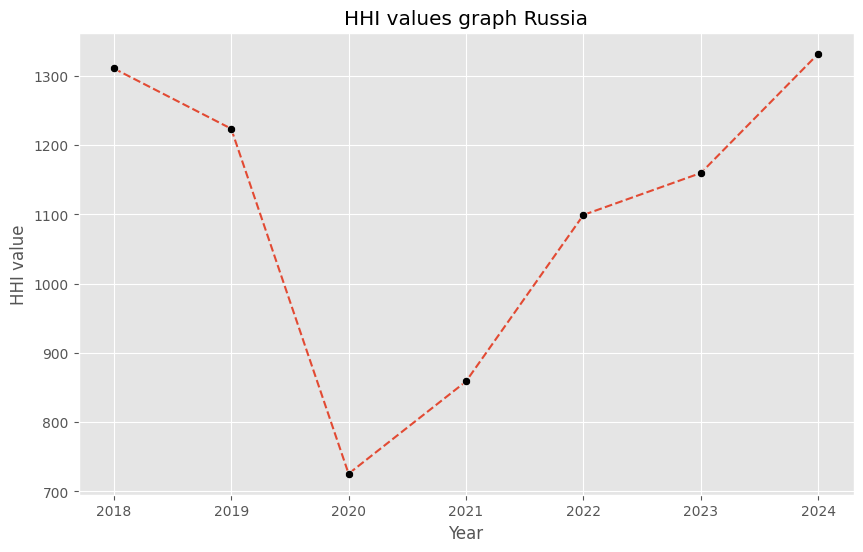

In [21]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=hhi_by_year.index, y=hhi_by_year, color='C0', ls='--')
sns.scatterplot(x=hhi_by_year.index, y=hhi_by_year, color='black', zorder=2)
plt.ylabel('HHI value')
plt.title('HHI values graph Russia')
plt.show()

Согласно результатам расчетов за 2018–2024 годы, индекс Херфиндаля-Хиршмана для мирового рынка калийных удобрений варьируется в диапазоне от 725,53 до 1332,16 пункта. Данные значения устойчиво находятся ниже пороговой отметки в 1500 пунктов, что свидетельствует о низком уровне концентрации и высокой (развитой) степени конкуренции на мировом рынке.

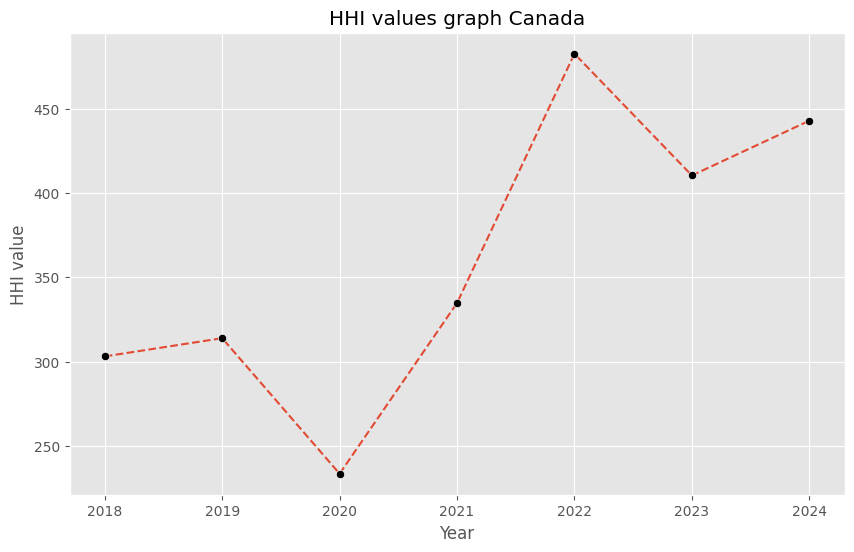

In [22]:
hhi_by_year_canada = hhi(country='Canada')

plt.figure(figsize=(10, 6))
sns.lineplot(x=hhi_by_year_canada.index, y=hhi_by_year_canada, color='C0', ls='--')
sns.scatterplot(x=hhi_by_year_canada.index, y=hhi_by_year_canada, color='black', zorder=2)
plt.ylabel('HHI value')
plt.title('HHI values graph Canada')
plt.show()

In [23]:
display(hhi_by_year_canada)

Year
2018    303.110546
2019    313.908281
2020    233.567915
2021    334.723404
2022    482.494978
2023    410.342673
2024    442.801173
dtype: float64

Теперь вычислим индекс сравнительного преимущества RCA:

$\text{RCA} = \frac{X_{c, p} / X_{c, total}}{X_{world, p} / X_{world, total}}$, где:
1.  $X_{c, p}$ — сколько страна $c$ экспортирует товара $p$. 
2. $X_{c, total}$ — сколько всего страна $c$ экспортирует (т.е. всех товаров).
3. $X_{world, p}$ — сколько весь мир экспортирует товар $p$.
4. $X_{world, total}$ — объем всей мировой торговли всеми товарами.

In [24]:
def compute_rca(hs6_id, country):

  df_country = df[df['Exporter Country'] == country]

  mask = df_country['HS6 ID'] == hs6_id
  X_c = df_country[mask].set_index('Year')['Trade Value']

  X_c_sum = df_country.groupby('Year')['Trade Value'].sum()

  X_word = df[df['HS6 ID'] == hs6_id].groupby('Year')['Trade Value'].sum()

  X_word_sum = df.groupby('Year')['Trade Value'].sum()

  RCA = (X_c / X_c_sum) / (X_word / X_word_sum)

  return RCA

In [25]:
rca_by_year = compute_rca(hs6_id = 6310490, country='Russia')

print('Среднее сравнительное преимущество России в экспорте Калийных удобрений 2018-2024 года:')
display(rca_by_year.mean().round(2))

Среднее сравнительное преимущество России в экспорте Калийных удобрений 2018-2024 года:


np.float64(3.06)

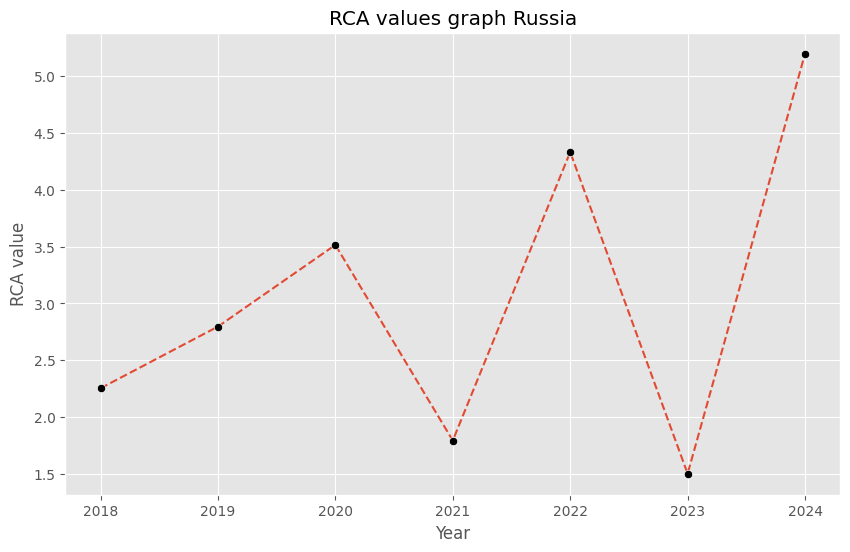

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=rca_by_year.index, y=rca_by_year, color='C0', ls='--')
sns.scatterplot(x=rca_by_year.index, y=rca_by_year, color='black', zorder=2)
plt.ylabel('RCA value')
plt.title('RCA values graph Russia')
plt.show()

Во все года с 2018 по 2024 индекс сравнительного преимущества в экспорте калийных удобрений превышал 1, а в среднем составлял 3.06, что математически подтверждает глубокую специализацию России на производстве и экспорте калийных удобрений. Повышение индекса сравнительного преимущества от $\text{RCA} = 1.5$ до $\text{RCA} = 5.2$ в 2024 году говорит об успешной адаптации к санкциям, введенным в 2022-2023 годах санкицям, а так же переориентации рынка на дружественные страны.

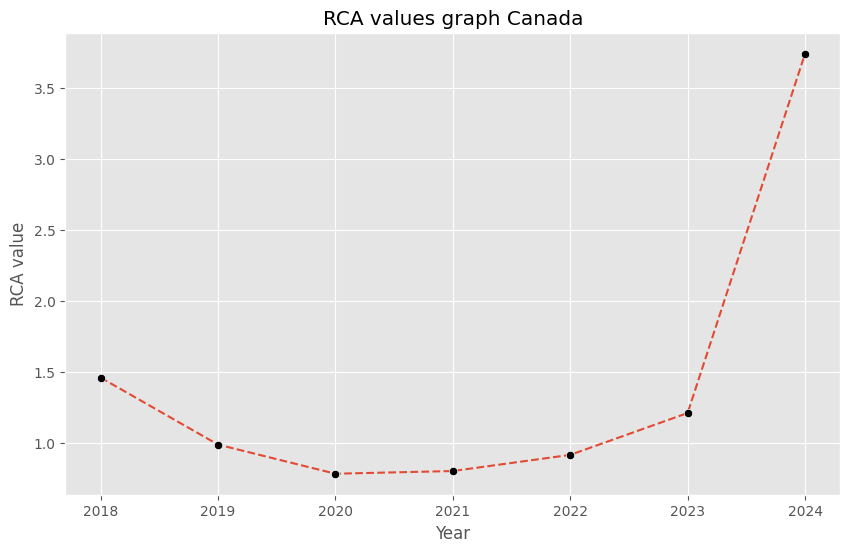

In [27]:
rca_by_year_canada = compute_rca(hs6_id = 6310490, country='Canada')

plt.figure(figsize=(10, 6))
sns.lineplot(x=rca_by_year_canada.index, y=rca_by_year_canada, color='C0', ls='--')
sns.scatterplot(x=rca_by_year_canada.index, y=rca_by_year_canada, color='black', zorder=2)
plt.ylabel('RCA value')
plt.title('RCA values graph Canada')
plt.show()

In [28]:
display(rca_by_year_canada)

Year
2018    1.462590
2019    0.991852
2020    0.786848
2021    0.805780
2022    0.919224
2023    1.213358
2024    3.737876
Name: Trade Value, dtype: float64

Вычислим индекс экономической сложности страны:

$\text{ECI} = \frac{k_{c} - \langle k_{c} \rangle}{\sigma(k_{c})}$, где $k_{c, n} = \frac{1}{k_{c, 0}} \sum\limits_{p}M_{cp}, k_{p, n-1}$, $k_{p, n} = \frac{1}{k_{p, 0}} \sum\limits_{c}M_{cp}, k_{c, n-1}$, $k_{c,0} = \sum\limits_{p}M_{cp}$, $k_{p, 0} = \sum\limits_{c}M_{cp}$, 

$M_{cp} = \begin{cases} 1, \ \text{RCA} \ge 1 \\ 0, \ \text{RCA} < 1 \end{cases}$

In [29]:
def compute_eci(df: pd.DataFrame):
    trade_matrix = df.groupby(['Exporter Country', 'HS6 ID'])['Trade Value'].sum().unstack(fill_value=0)

    X_c = trade_matrix.sum(axis=1)
    X_p = trade_matrix.sum(axis=0)
    X_w = trade_matrix.sum().sum()

    rca_matrix = trade_matrix.div(X_c, axis=0).div(X_p / X_w, axis=1)

    M = (rca_matrix >= 1).astype(int)

    k_c_0 = M.sum(axis=1)
    k_c_0 = k_c_0[k_c_0 != 0]

    k_p_0 = M.sum(axis=0)
    k_p_0 = k_p_0[k_p_0 != 0]

    for _ in range(0, 20):

      if _ == 0:
        k_c_k = k_c_0
        k_p_k = k_p_0

      k_c_n = (M @ k_p_k) / k_c_0
      k_p_n = (M.T @ k_c_k) / k_p_0

      k_c_k = k_c_n
      k_p_k = k_p_n

    return (k_c_n - k_c_n.mean()) / (k_c_n.std())

In [30]:
ECI = df.groupby('Year').apply(compute_eci) # Здесь сама матрица для всех стран
print('Средний индекс ECI по годам для России')
display(ECI['Russia'].mean().round(2))

Средний индекс ECI по годам для России


np.float64(0.73)

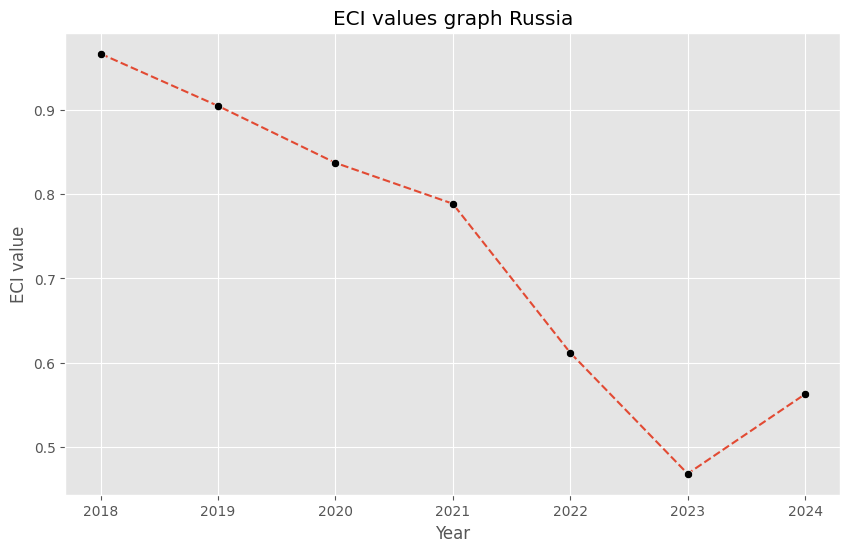

In [31]:
ECI_russia = ECI['Russia']

plt.figure(figsize=(10, 6))
sns.lineplot(x=ECI_russia.index, y=ECI_russia, color='C0', ls='--')
sns.scatterplot(x=ECI_russia.index, y=ECI_russia, color='black', zorder=2)
plt.ylabel('ECI value')
plt.title('ECI values graph Russia')
plt.show()

Индекс экономической сложности ECI показывает интересную тенденцию: с 2018 по 2023 год он падает, а в 2024 году растет. На протяжении всего периода ECI сохранял положительную величину, что свидетельствует о сохранении уровня диверсификации и технологичности, превышая средне-мировые показатели. Динамика ECI может быть связана со следующими причинами:

1. 2018-2019 год - рост и развитие технологических производств в мире, повышение общего уровня сложности мира.
2. 2020-2022 - последствия ковида
3. 2022-2023 - санкции, накладываемые на Россию.

Рост в 2024 году же связан с адаптацией росийского экспорта на рынки дружественных стран.

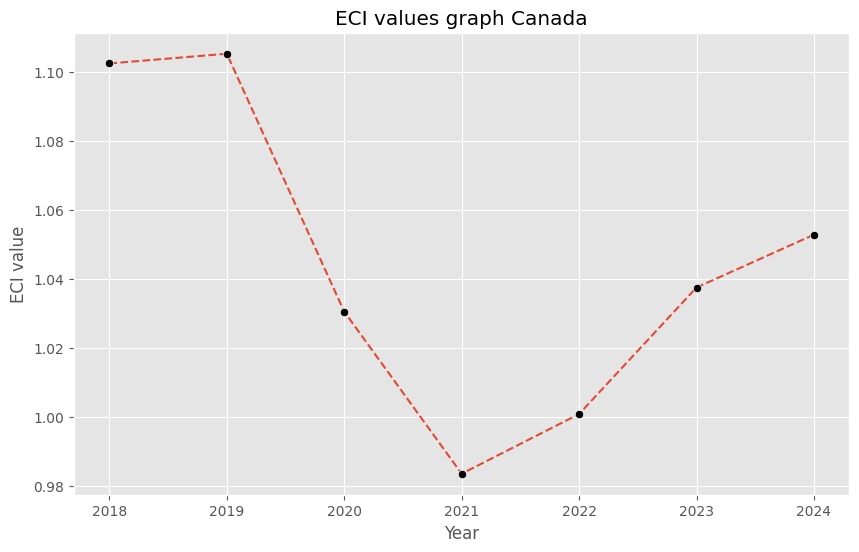

In [32]:
ECI_canada = ECI['Canada']

plt.figure(figsize=(10, 6))
sns.lineplot(x=ECI_canada.index, y=ECI_canada, color='C0', ls='--')
sns.scatterplot(x=ECI_canada.index, y=ECI_canada, color='black', zorder=2)
plt.ylabel('ECI value')
plt.title('ECI values graph Canada')
plt.show()

In [33]:
display(ECI_canada)

Year
2018    1.102504
2019    1.105328
2020    1.030553
2021    0.983563
2022    1.000862
2023    1.037547
2024    1.052865
Name: Canada, dtype: float64

# Гравитационная модель

In [34]:
df_potash_import['iso3_o'] = df_potash_import['Exporter Country'].map(country_to_iso3)
df_potash_import['iso3_d'] = df_potash_import['Importer Country'].map(country_to_iso3)
df_potash_import['Year'] = df_potash_import['Year'].astype(int)
df_potash_import = df_potash_import.dropna(subset=['iso3_o', 'iso3_d'])

merge_columns = ['Year', 'iso3_o', 'iso3_d', 'gdp_o', 'gdp_d', 'dist', 'contig', 'comlang_off', 'fta_wto', 'Trade Value']

geo_columns = ['iso3_o', 'iso3_d', 'dist', 'contig', 'comlang_off', 'fta_wto']
df_geo_passport = df_cepii[geo_columns].drop_duplicates(subset=['iso3_o', 'iso3_d'])

df_gravity = df_potash_import.merge(
    right=df_geo_passport,
    how='inner', 
    on=['iso3_o', 'iso3_d']
) 

for_merge = ['iso3_o', 'iso3_d', 'Trade Value', 'Year', 'dist', 'contig', 'comlang_off', 'fta_wto']
df_gravity = df_gravity.loc[:, for_merge]

In [35]:
countries_o = [c for c in df_gravity['iso3_o'].unique() if isinstance(c, str)]
countries_d = [c for c in df_gravity['iso3_d'].unique() if isinstance(c, str)]

df_wb_gdp_o = load_wb_indicator_batch(countries=countries_o, indicator="NY.GDP.MKTP.CD")\
    .rename(columns=({'country_code': 'iso3_o', 'year': 'Year', 'value': 'gdp_o'}))\
        .dropna().drop(columns=('country'))
df_wb_gdp_d = load_wb_indicator_batch(countries=countries_d, indicator="NY.GDP.MKTP.CD")\
    .rename(columns=({'country_code': 'iso3_d', 'year': 'Year', 'value': 'gdp_d'}))\
        .dropna().drop(columns=('country'))

df_gravity = df_gravity.merge(
    right=df_wb_gdp_o,
    how='left',
    on=['Year', 'iso3_o']
)

df_gravity = df_gravity.merge(
    right=df_wb_gdp_d,
    how='left',
    on=['Year', 'iso3_d']
)

df_gravity['dist'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['dist'].ffill().bfill()
df_gravity['contig'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['contig'].ffill().bfill()
df_gravity['comlang_off'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['comlang_off'].ffill().bfill()
df_gravity['fta_wto'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['fta_wto'].ffill().bfill()

df_gravity = df_gravity.dropna()

Далее будем оценивать страны с помощью гравитационной модели Пуассона (PPML):

$$E[\text{Trade Value}_{ij}] = \exp(\beta_0 + \beta_1 \ln(\text{gdp\_o}_{i}) + \beta_2 \ln(\text{gdp\_d}_{j}) + \beta_3 \ln(\text{dist}_{ij}) + \gamma \mathbf{X}_{ij})$$

1. Trade Value - объем торговли
2. gdp_o - ВВП экспортера
3. gdp_d - ВВР импортера
4. dist - расстояние между странами
5. $\mathbf{X}_{ij}$ — вектор дамми-переменных, включающий наличие общей границы (contig), общего языка (comlang_off) и действие торговых соглашений (fta_wto)

In [36]:
features = ['Trade Value', 'gdp_o', 'gdp_d', 'dist', 'contig', 'comlang_off', 'fta_wto', 'iso3_o', 'iso3_d']
years_result = []

for year in df_gravity.sort_values(by='Year', ascending=True)['Year'].unique():

    mask = df_gravity['Year'] == year
    df_year = df_gravity[mask].loc[:, features]
    
    df_year['ln_gdp_o'] = np.log(df_year['gdp_o'])
    df_year['ln_gdp_d'] = np.log(df_year['gdp_d'])
    df_year['ln_dist'] = np.log(df_year['dist'])
    
    model_cols = ['ln_gdp_o', 'ln_gdp_d', 'ln_dist', 'contig', 'comlang_off', 'fta_wto', 'Trade Value']
    df_year = df_year.replace([np.inf, -np.inf], np.nan).dropna(subset=model_cols)
    
    y = df_year['Trade Value']
    X = df_year.drop(columns=['Trade Value', 'gdp_o', 'gdp_d', 'dist', 'iso3_d', 'iso3_o'])    

    X = sm.add_constant(X)
    grav_model = sm.Poisson(y, X)
    results = grav_model.fit(cov_type='HC3')

    df_year['Predict'] = results.predict(X)
    df_year['Delta'] = df_year['Predict'] - df_year['Trade Value']
    df_pred_year = df_year.loc[:, ['iso3_o', 'iso3_d', 'Trade Value', 'Predict', 'Delta']]

    years_result.append([int(year), df_pred_year])

Optimization terminated successfully.
         Current function value: 14131086.220189
         Iterations 8
Optimization terminated successfully.
         Current function value: 14342808.386790
         Iterations 8
Optimization terminated successfully.
         Current function value: 12701193.667340
         Iterations 8
Optimization terminated successfully.
         Current function value: 18044573.037168
         Iterations 8
Optimization terminated successfully.
         Current function value: 29396745.726372
         Iterations 8
Optimization terminated successfully.
         Current function value: 21556626.556259
         Iterations 8
Optimization terminated successfully.
         Current function value: 18109567.066866
         Iterations 8


In [37]:
print('Оценка гравитационной модели экспорта калийных удобрений за 2024 год')
print(results.summary())

print()

print('Значения p-value для выбранных переменных')

p_values_df = pd.DataFrame({'p-values': results.pvalues}).round(2)
p_values_df['stat singificace'] = np.where(p_values_df['p-values'] <= 0.01, '*', np.where(p_values_df['p-values'] <= 0.05, '**', np.where(p_values_df['p-values'] <= 0.1, '***', 'not')))

display(p_values_df)
print('***: p-value <= 0.1, **: p-value <= 0.05, *: p-value <= 0.01')

Оценка гравитационной модели экспорта калийных удобрений за 2024 год
                          Poisson Regression Results                          
Dep. Variable:            Trade Value   No. Observations:                 3258
Model:                        Poisson   Df Residuals:                     3251
Method:                           MLE   Df Model:                            6
Date:                Wed, 27 May 2026   Pseudo R-squ.:                  0.2972
Time:                        23:18:21   Log-Likelihood:            -5.9001e+10
converged:                       True   LL-Null:                   -8.3955e+10
Covariance Type:                  HC3   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -6.8590      3.617     -1.896      0.058     -13.948       0.230
contig          1.8904      0.347      5.444      0.000    

,p-values,stat singificace
const,0.06,***
contig,0.00,*
comlang_off,0.52,not
fta_wto,0.65,not
ln_gdp_o,0.01,*
ln_gdp_d,0.00,*
ln_dist,0.50,not


***: p-value <= 0.1, **: p-value <= 0.05, *: p-value <= 0.01


Для экспорта калийных удобрений в 2024 году гравитационная модель подтвердила статистическую значимость на уровне p-value <= 0.05 следующий категорий: константы, наличия общей границы и ввп стран импортеров и экспортеров, что показывает незначимость общих союзов или членства ВТО, расстояния и общего языка в экспорте удобрений. Данные переменные показывают тенденции к переменам на рынке калийных удобрений, сводящиеся к простоте логистики и экономическим возможностям экспортера. При этом значима и экономическая ситуация страны-импортера, что может указывать на дефицит удобрений, находящихся на мировом рынке после глобальных изменений.

Будем измерять потенциал стран как $\Delta = \text{Model Predict} - \text{Real Data}$, чем больше $\Delta$, тем больше у страны есть потенциал к торговле. 

In [38]:
for object in years_result:
    year = object[0]
    df_pred_year = object[1]
    df_pred_year = df_pred_year[df_pred_year['iso3_o'] == 'RUS'].drop(columns='iso3_o')
    df_pred_year['iso3_d'] = df_pred_year['iso3_d'].copy().map(iso3_to_ru)
    df_pred_year = df_pred_year[df_pred_year['Trade Value'] >= 100]

    df_very_big = df_pred_year.sort_values(by='Delta', ascending=True).head(10)
    df_very_big = df_very_big[df_very_big['Delta'] < 0]

    print('=' * 80)
    print(f'Топ 10 стран с сверхинтенсивным экспортом для {year} года')
    print('=' * 80)

    display(df_very_big.round(2))

Топ 10 стран с сверхинтенсивным экспортом для 2018 года


,iso3_d,Trade Value,Predict,Delta
16540,Бразилия,824696560.0,1.328166e+07,-8.114149e+08
16583,Китай,577451579.0,2.056555e+08,-3.717961e+08
16747,Индия,248657340.0,1.511559e+07,-2.335418e+08
17072,Украина,242684280.0,1.223134e+07,-2.304529e+08
16754,Индонезия,178271067.0,9.224456e+06,-1.690466e+08
17087,США,200303618.0,4.935647e+07,-1.509471e+08
17076,ОАЭ,122636825.0,5.264039e+06,-1.173728e+08
16938,Польша,145014836.0,2.960722e+07,-1.154076e+08
16679,Финляндия,108698123.0,1.868815e+07,-9.000997e+07
16844,Малайзия,93446143.0,4.980140e+06,-8.846600e+07


Топ 10 стран с сверхинтенсивным экспортом для 2019 года


,iso3_d,Trade Value,Predict,Delta
16541,Бразилия,1.024758e+09,1.413669e+07,-1.010621e+09
16584,Китай,8.224722e+08,2.428472e+08,-5.796250e+08
16748,Индия,2.203626e+08,1.684729e+07,-2.035153e+08
17088,США,2.064279e+08,5.527494e+07,-1.511529e+08
16755,Индонезия,1.585598e+08,1.033982e+07,-1.482200e+08
17073,Украина,1.424825e+08,1.369228e+07,-1.287902e+08
16671,Эстония,1.204879e+08,6.231804e+06,-1.142561e+08
16680,Финляндия,1.140056e+08,2.112974e+07,-9.287583e+07
17077,ОАЭ,9.819318e+07,5.611765e+06,-9.258141e+07
16939,Польша,1.214966e+08,3.433354e+07,-8.716310e+07


Топ 10 стран с сверхинтенсивным экспортом для 2020 года


...

,iso3_d,Trade Value,Predict,Delta
16544,Бразилия,3.291957e+09,3.085106e+07,-3.261106e+09
16751,Индия,8.261861e+08,3.498210e+07,-7.912040e+08
16758,Индонезия,7.314246e+08,2.298746e+07,-7.084372e+08
17091,США,7.500190e+08,1.325600e+08,-6.174590e+08
16587,Китай,1.039527e+09,4.998813e+08,-5.396457e+08
17045,Таиланд,1.887668e+08,1.188507e+07,-1.768818e+08
16848,Малайзия,1.664585e+08,1.090906e+07,-1.555494e+08
16599,Колумбия,1.392869e+08,1.058041e+07,-1.287064e+08
16972,Сербия,1.103280e+08,2.515501e+06,-1.078125e+08
16858,Мексика,1.324242e+08,2.536755e+07,-1.070567e+08


Топ 10 стран с сверхинтенсивным экспортом для 2023 года


,iso3_d,Trade Value,Predict,Delta
16545,Бразилия,1.922541e+09,2.059329e+07,-1.901948e+09
16752,Индия,1.034863e+09,2.493942e+07,-1.009924e+09
16588,Китай,1.300666e+09,4.037864e+08,-8.968794e+08
16759,Индонезия,4.454411e+08,1.474351e+07,-4.306975e+08
17092,США,3.882678e+08,9.545484e+07,-2.928129e+08
16849,Малайзия,2.237484e+08,6.601061e+06,-2.171474e+08
17046,Таиланд,1.980992e+08,7.596845e+06,-1.905023e+08
16809,Кения,1.141749e+08,2.757020e+06,-1.114179e+08
17113,Вьетнам,1.090335e+08,6.897168e+06,-1.021364e+08
16973,Сербия,8.158745e+07,1.890899e+06,-7.969655e+07


Топ 10 стран с сверхинтенсивным экспортом для 2024 года


,iso3_d,Trade Value,Predict,Delta
16546,Бразилия,1.912505e+09,1.668622e+07,-1.895818e+09
16589,Китай,1.418140e+09,3.665486e+08,-1.051592e+09
16753,Индия,9.077486e+08,2.128410e+07,-8.864645e+08
16760,Индонезия,4.432876e+08,1.247957e+07,-4.308080e+08
17093,США,4.781086e+08,7.196876e+07,-4.061398e+08
16850,Малайзия,2.822793e+08,6.086453e+06,-2.761928e+08
17047,Таиланд,2.356434e+08,6.819288e+06,-2.288242e+08
16944,Польша,1.895246e+08,5.079630e+07,-1.387283e+08
16974,Сербия,8.824902e+07,2.054430e+06,-8.619459e+07
16810,Кения,7.593081e+07,2.829476e+06,-7.310134e+07


In [39]:
for object in years_result:
    year = object[0]
    df_pred_year = object[1]
    df_pred_year = df_pred_year[df_pred_year['iso3_o'] == 'RUS'].drop(columns='iso3_o')
    df_pred_year['iso3_d'] = df_pred_year['iso3_d'].copy().map(iso3_to_ru)
    df_pred_year = df_pred_year[df_pred_year['Trade Value'] >= 100]

    df_no_use_potential = df_pred_year.sort_values(by='Delta', ascending=False).head(15)
    df_no_use_potential = df_no_use_potential[df_no_use_potential['Delta'] > 0]

    print('=' * 80)
    print(f'Топ 15 стран с нереализованным потенциалом экспорта для {year} года')
    print('=' * 80)

    display(df_no_use_potential.round(2))

Топ 15 стран с нереализованным потенциалом экспорта для 2018 года


,iso3_d,Trade Value,Predict,Delta
16894,Норвегия,3220757.0,25641781.19,22421024.19
16704,Германия,3729375.0,17434952.69,13705577.69
16785,Япония,10503876.0,22214356.84,11710480.84
16500,Австралия,20903.0,11438917.75,11418014.75
17001,Южная Корея,1466050.0,12349886.54,10883836.54
16797,Казахстан,11912831.0,20609862.24,8697031.24
16519,Беларусь,895084.0,7787239.80,6892155.80
17027,Швейцария,953426.0,6717815.60,5764389.60
16975,Сингапур,117719.0,5137606.76,5019887.76
16994,ЮАР,673423.0,5427750.06,4754327.06


Топ 15 стран с нереализованным потенциалом экспорта для 2019 года


,iso3_d,Trade Value,Predict,Delta
16895,Норвегия,4189580.0,28205740.06,24016160.06
16705,Германия,2958194.0,18777983.53,15819789.53
16501,Австралия,97394.0,12135336.16,12037942.16
17002,Южная Корея,3705795.0,13038471.24,9332676.24
16798,Казахстан,11558222.0,20432112.19,8873890.19
16779,Италия,5376949.0,13130930.95,7753981.95
16520,Беларусь,1013647.0,8241839.38,7228192.38
17028,Швейцария,938248.0,7234701.44,6296453.44
16933,Филиппины,165097.0,5490997.94,5325900.94
16774,Израиль,58050.0,5232380.21,5174330.21


Топ 15 стран с нереализованным потенциалом экспорта для 2020 года


...

,iso3_d,Trade Value,Predict,Delta
16898,Норвегия,2304486.0,44567098.90,42262612.90
16789,Япония,4433249.0,44547461.93,40114212.93
16801,Казахстан,20376988.0,52358242.18,31981254.18
16961,Саудовская Аравия,8760.0,17592145.98,17583385.98
16876,Нидерланды,777149.0,14128145.45,13350996.45
17031,Швейцария,112210.0,12322587.06,12210377.06
17005,Южная Корея,13631294.0,25614724.29,11983430.29
16580,Чили,248926.0,10343262.00,10094336.00
16936,Филиппины,2559077.0,10896745.84,8337668.84
16683,Финляндия,16763066.0,24375537.17,7612471.17


Топ 15 стран с нереализованным потенциалом экспорта для 2023 года


,iso3_d,Trade Value,Predict,Delta
16790,Япония,286416.0,29105306.82,28818890.82
16684,Финляндия,2136645.0,21497918.99,19361273.99
17006,Южная Корея,40831.0,16898295.56,16857464.56
16802,Казахстан,20867104.0,32451558.72,11584454.72
16877,Нидерланды,3282.0,10451827.92,10448545.92
17032,Швейцария,565232.0,9011917.70,8446685.70
16892,Нигерия,441599.0,7189598.87,6747999.87
16581,Чили,102623.0,6426134.36,6323511.36
16777,Израиль,180000.0,6501911.68,6321911.68
17081,ОАЭ,977881.0,6929216.32,5951335.32


Топ 15 стран с нереализованным потенциалом экспорта для 2024 года


,iso3_d,Trade Value,Predict,Delta
16791,Япония,555632.0,22678151.85,22122519.85
17007,Южная Корея,33071.0,14270930.32,14237859.32
16685,Финляндия,11289223.0,25516760.62,14227537.62
16803,Казахстан,21180068.0,33574405.36,12394337.36
16962,Саудовская Аравия,55940.0,10409310.30,10353370.30
16676,Эстония,21527.0,8162579.66,8141052.66
16838,Литва,4395241.0,12018149.56,7622908.56
17033,Швейцария,1351794.0,8362644.98,7010850.98
16878,Нидерланды,3225220.0,9718815.45,6493595.45
16825,Латвия,1911113.0,8196423.20,6285310.20


Тут стоит смотреть на последние года, так как в них произошли глобальные изменения в стране. Смотрим за 2022-2024 года: видно большую неоднородность рынка, каждый раз модель предсказывает новые страны, в целом все страны из списка могут быть кандидатами с математической точки зрения. Выбирая по географическому положению, потенциальному спросу и аграрному развитию страны кандидатами становятся: Казахстан и Чили как агропромышленные страны.

# Анализ панельных данных

In [40]:
df_comtarade = df_potash_comtrade.copy().loc[:, ['period', 'primaryValue']].rename(columns={'primaryValue': 'potash value'})\
    .merge(right=df_gas_comtrade.copy().loc[:, ['period', 'primaryValue']].rename(columns={'primaryValue': 'gas value'}), on='period', how='left')\
        .merge(right=df_tomato_comtrade.copy().loc[:, ['period', 'primaryValue']].rename(columns={'primaryValue': 'tomato value'}), on='period', how='left')\
            .rename(columns={'period': 'date'})
df_comtarade['date'] = pd.to_datetime(df_comtarade['date'], format='%Y%m')
df_comtarade = df_comtarade.set_index('date').sort_index(ascending=True).fillna(0)

Построим несколько обзорных графиков

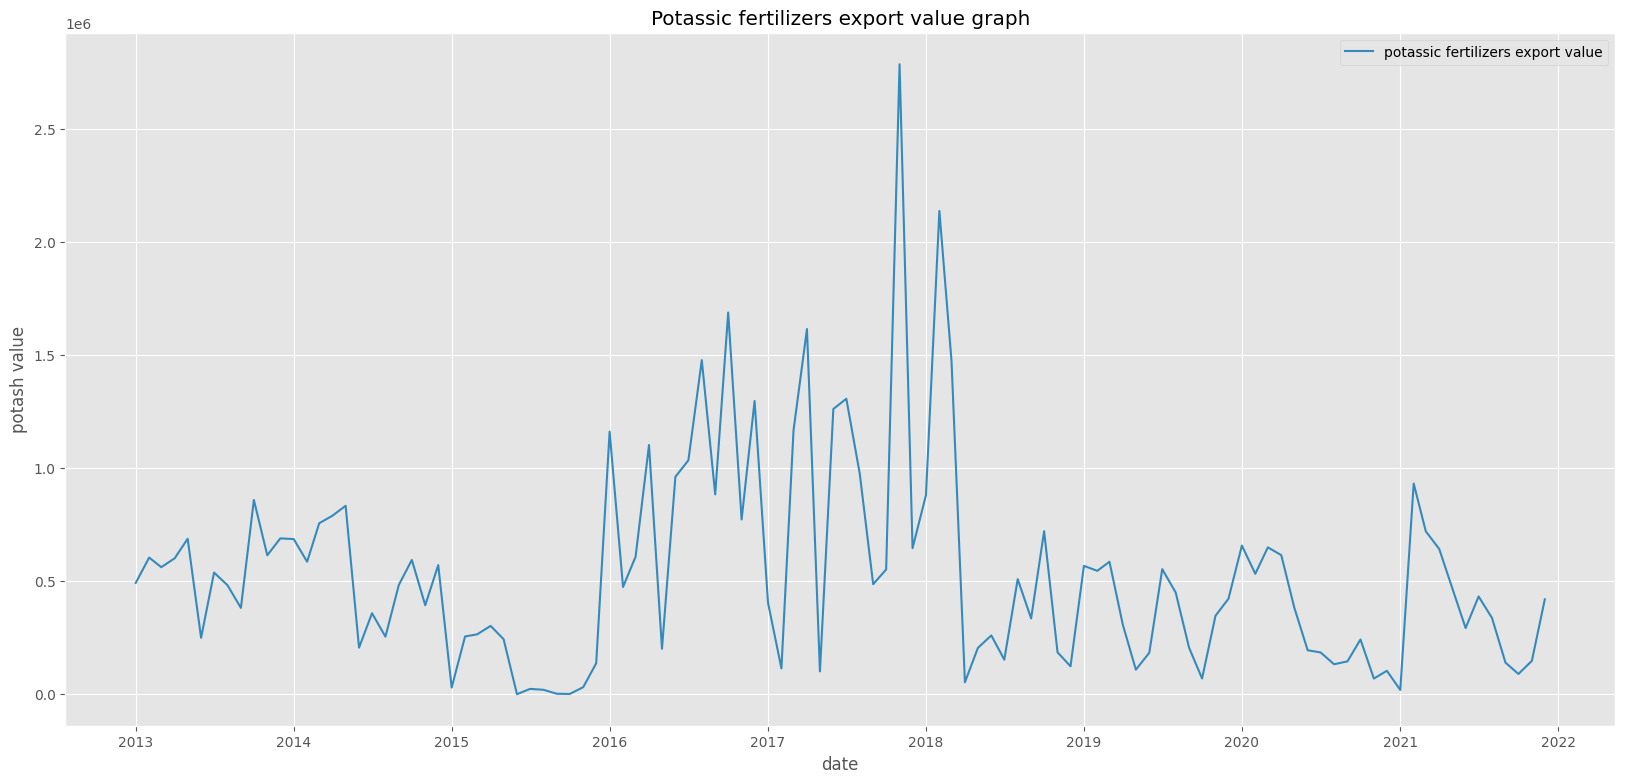

In [41]:
df_potash_time = df_comtarade.loc[:, ['potash value']]

plt.figure(figsize=(20, 9))
sns.lineplot(x=df_potash_time.index, y=df_potash_time['potash value'], color='C1', label='potassic fertilizers export value')
plt.title('Potassic fertilizers export value graph')
plt.show()

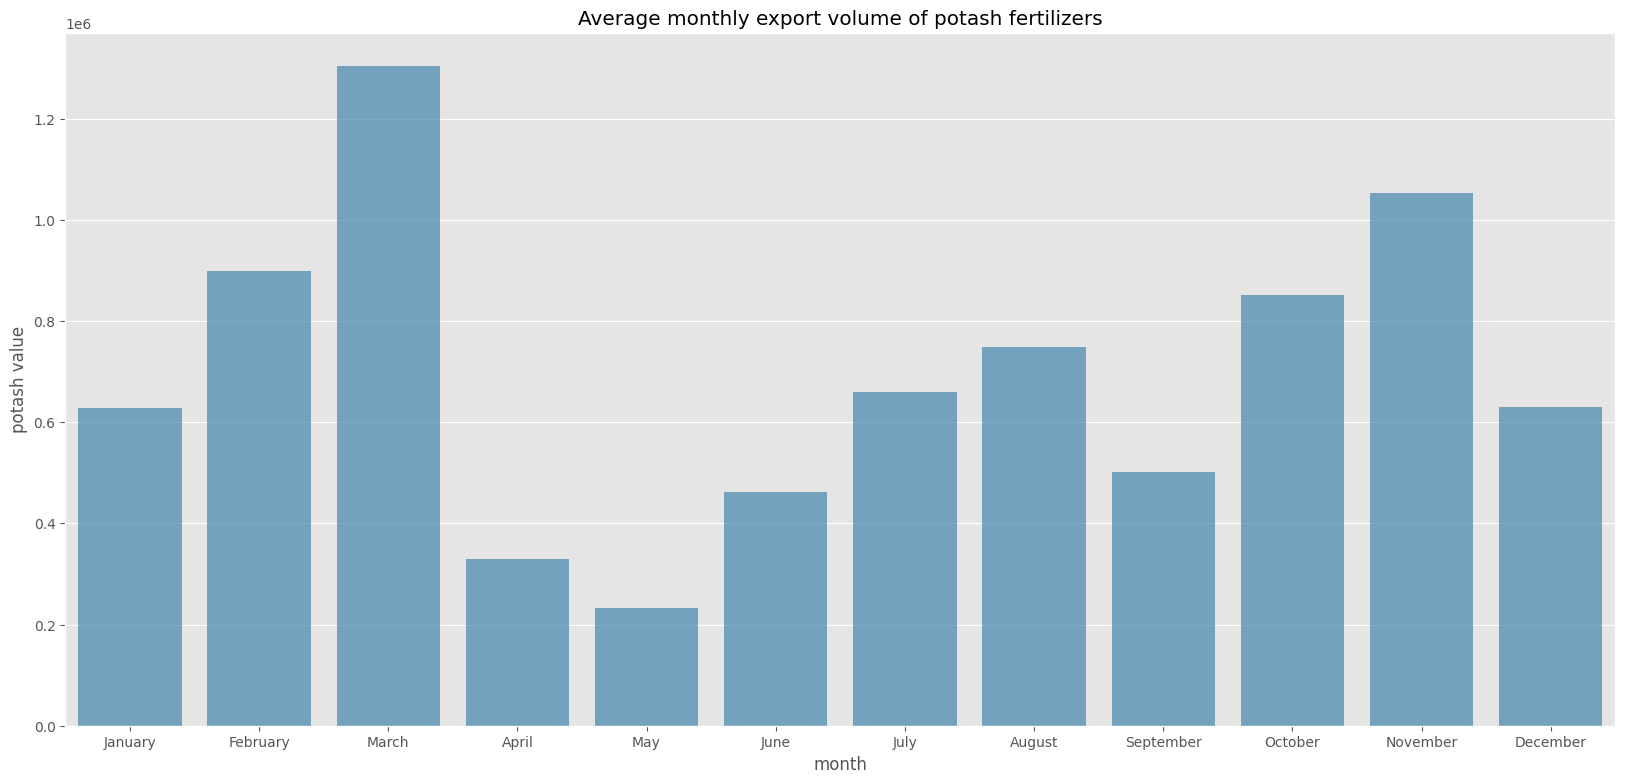

In [42]:
df_potash_time["month_num"] = df_potash_time.index.month
month_mean = df_potash_time.groupby(['month_num']).mean()
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_mean['month'] = months
month_mean = month_mean.set_index('month')

plt.figure(figsize=(20, 9))
sns.barplot(x=month_mean.index, y=month_mean['potash value'], color='C1', alpha=0.7)
plt.title('Average monthly export volume of potash fertilizers')
plt.show()

Как видим, в среднем в июне и декабре самые большие значения экспорта удобрений, что может говорить о сезонности. Проверим это с помощью STL-декомпозиции:

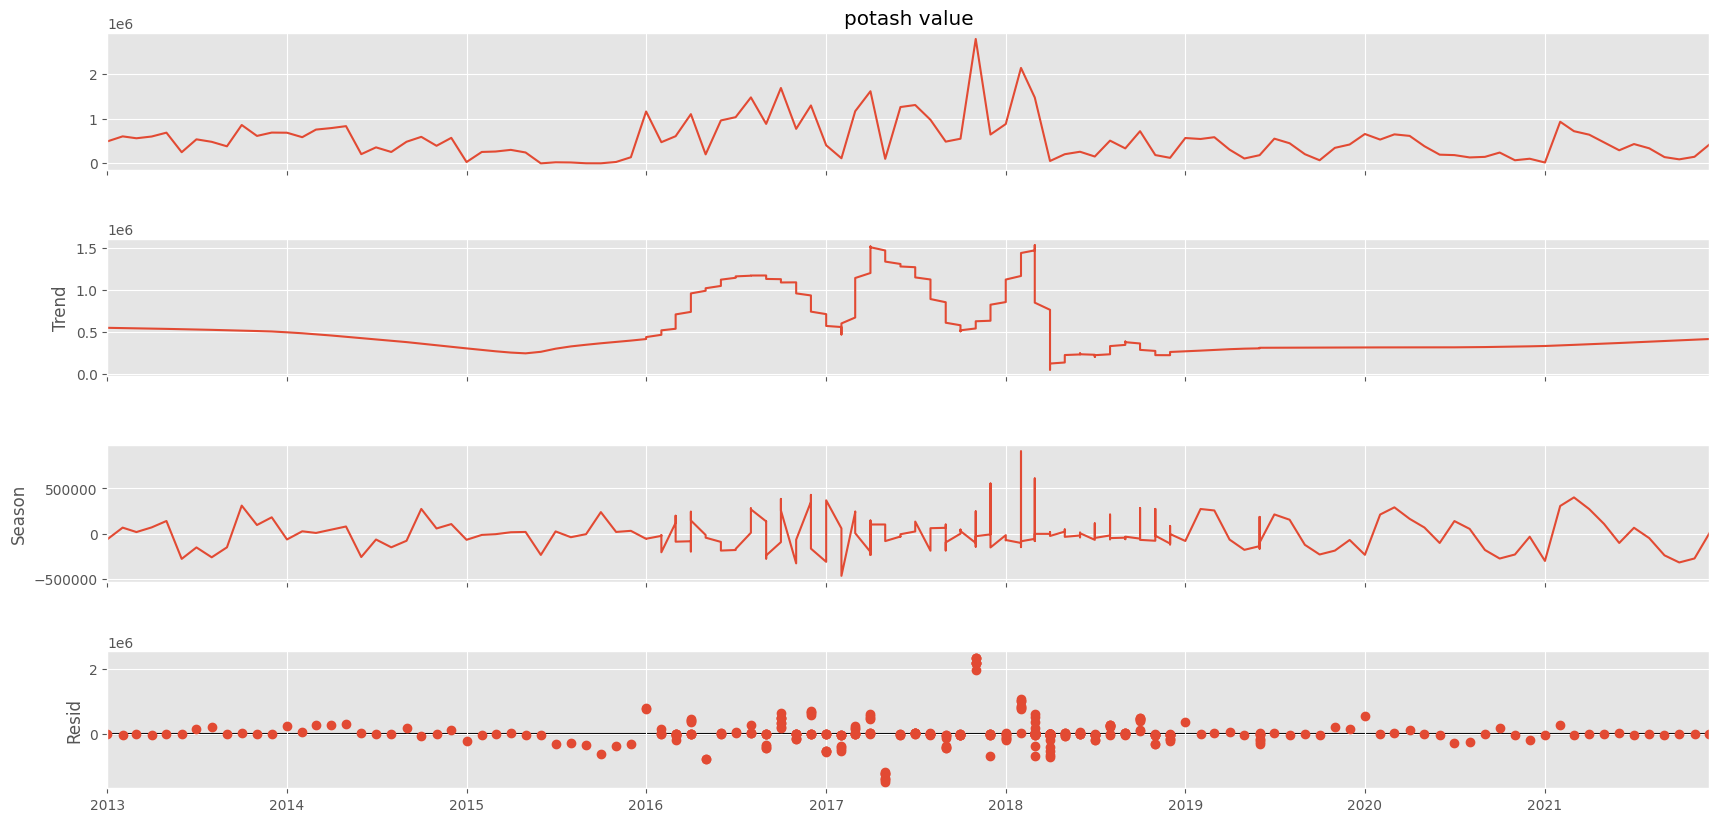

In [43]:
stl = STL(df_potash_time['potash value'], period=12, robust=True, seasonal=7)
results = stl.fit()

fig = results.plot()
fig.set_size_inches(20, 9)
fig.show()

Сезонности особо не наблюдается, но так же наблюдается бум значений в 2017 году, где на максимумы пришлись как раз июнь и декабрь, что сильно завышает их среднее. 

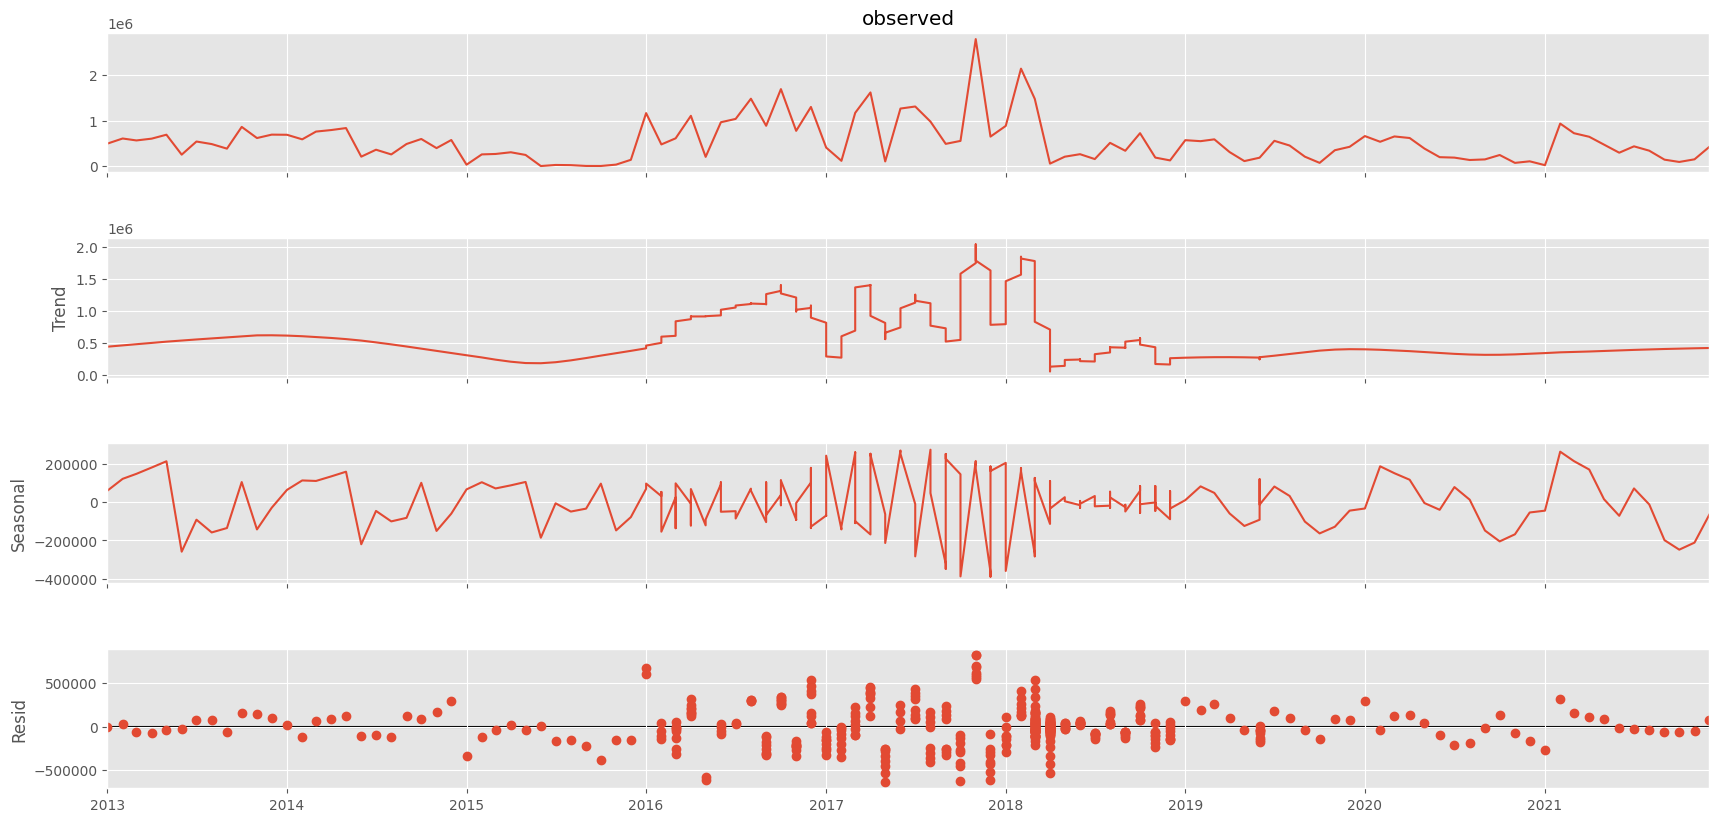

In [44]:
mstl = MSTL(df_potash_time['potash value'], periods=12)
res = mstl.fit()

fig = res.plot()
fig.set_size_inches(20, 9)
plt.show()

Вот тут уже проявляется сезонность, она как-будто более периодична, чем у STL, значит сезонность все же есть, но ее период составляет 3-5 месяцев.

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

def MAE(real: pd.Series, pred: pd.Series):
  return mean_absolute_error(real, pred)

def MAPE(real: pd.Series, pred: pd.Series):
  return mean_absolute_percentage_error(real, pred)

def sMAPE(real: pd.Series, pred: pd.Series): # Я брал формулу отсюда: https://en.wikipedia.org/wiki/Symmetric_mean_absolute_percentage_error

  if len(real) != len(pred):
    raise ValueError('Число реальных данных и предиктов должно совпадать!')

  real = np.array(real)
  pred = np.array(pred)

  diff = abs(real - pred)
  znam = abs(real) + abs(pred)

  drob = diff / znam

  return 2 / len(drob) * drob.sum()

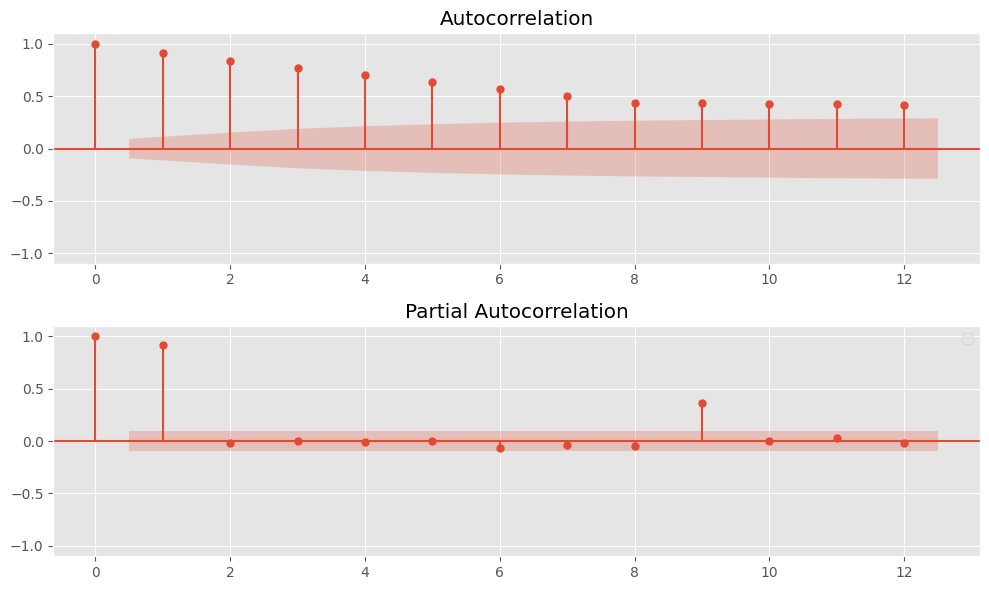

In [46]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

plot_acf(x=df_potash_time['potash value'], lags=12, ax=ax[0])
ax[0].set_title('Autocorrelation')
ax[0].set_ylim(-1.1, 1.1)

plot_pacf(x=df_potash_time['potash value'], lags=12, ax=ax[1])
ax[1].set_title('Partial Autocorrelation')
ax[1].set_ylim(-1.1, 1.1)


plt.legend()
plt.tight_layout()
plt.show()

Наблюдается не сильная кореляция между текущими значениями и прошлыми, кореляции в основном достаточном маленькие, скорее просто случайные. Каких-то повторяющихся "пиков" нету, значит и сезонность отсутствует.

В итоге ACF и PACF показали отсутствие сезонности, вероятно MSTL включил некоторые шумы и нестабильность в сезонность, что и привело к соответствующему графику.

Далее проведем ADF и KPSS тесты

In [47]:
# Взято отсюда: https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [48]:
adf_test(df_potash_time['potash value'])
print()
kpss_test(df_potash_time['potash value'])

Results of Dickey-Fuller Test:
Test Statistic                  -1.988175
p-value                          0.291782
#Lags Used                      16.000000
Number of Observations Used    428.000000
Critical Value (1%)             -3.445721
Critical Value (5%)             -2.868317
Critical Value (10%)            -2.570380
dtype: float64

Results of KPSS Test:
Test Statistic            0.903964
p-value                   0.010000
Lags Used                12.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


Мы видим, что ADF p-value < 0.05 и KPSS p-value < 0.05, значит ряд не стационарен, дальше будем работать с первыми разностями:

Рассмотрим модели ARIMA, SARIMA, SARIMAX

In [49]:
df_potash_time = df_potash_time.diff(1)

arima_model = SARIMAX(endog=df_potash_time['potash value'], order=(1, 1, 1), trend='c')

sarima_model = SARIMAX(endog=df_potash_time['potash value'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')


exog = df_comtarade.drop(columns=['potash value'])
sarimax_model = SARIMAX(endog=df_potash_time['potash value'], exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')

In [50]:
arima_res = arima_model.fit()
print(arima_res.summary())

                               SARIMAX Results                                
Dep. Variable:           potash value   No. Observations:                  445
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -6172.446
Date:                Wed, 27 May 2026   AIC                          12352.892
Time:                        23:18:23   BIC                          12369.275
Sample:                             0   HQIC                         12359.353
                                - 445                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -16.9994    166.211     -0.102      0.919    -342.766     308.767
ar.L1         -0.0259      0.212     -0.122      0.903      -0.442       0.390
ma.L1         -0.9984      0.022    -45.291      0.0

In [51]:
sarima_res = sarima_model.fit()
print(sarima_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       potash value   No. Observations:                  445
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -6066.058
Date:                            Wed, 27 May 2026   AIC                          12144.116
Time:                                    23:18:23   BIC                          12168.526
Sample:                                         0   HQIC                         12153.753
                                            - 445                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    560.0717    715.322      0.783      0.434    -841.934    1962.077
ar.L1         -0.0192      0.296   

In [52]:
sarimax_res = sarimax_model.fit()
print(sarimax_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       potash value   No. Observations:                  445
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -6063.303
Date:                            Wed, 27 May 2026   AIC                          12142.606
Time:                                    23:18:24   BIC                          12175.153
Sample:                                         0   HQIC                         12155.456
                                            - 445                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       99.9642    222.833      0.449      0.654    -336.780     536.708
gas value        0.0068      

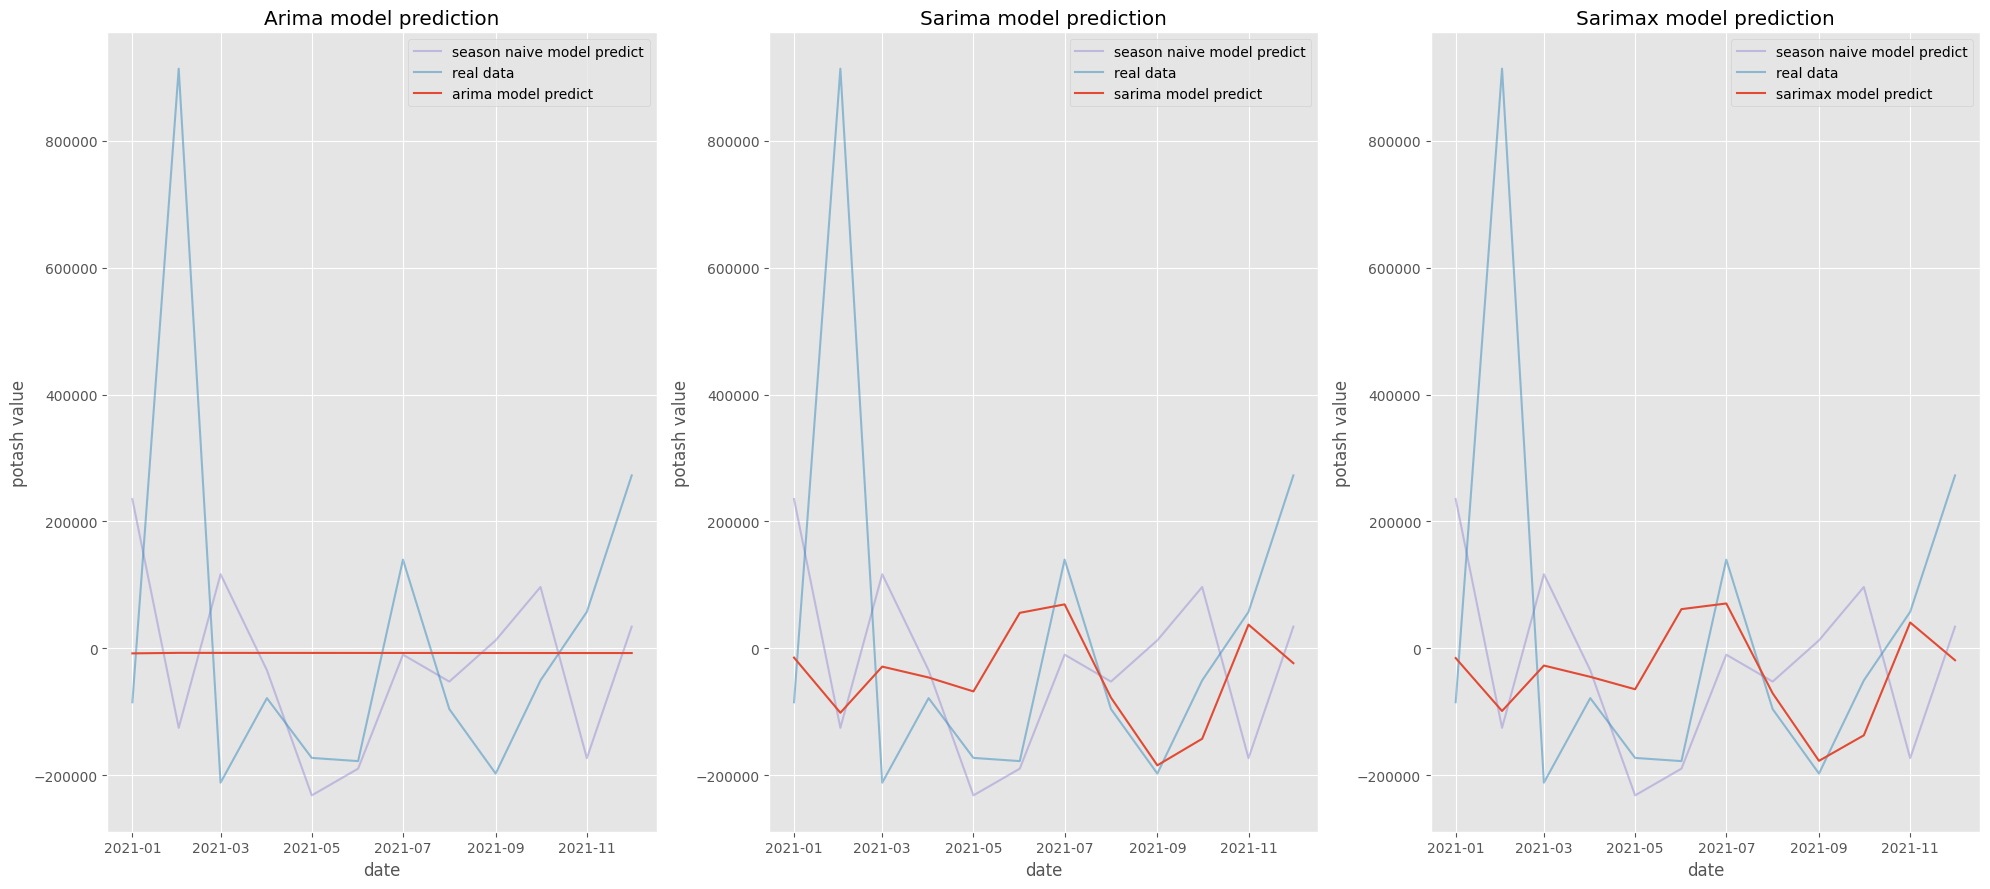

In [53]:
alpha=0.5

df_train, df_test = df_potash_time.iloc[:-12], df_potash_time.iloc[-12:]
exog_train, exog_test = exog.iloc[:-12], exog.iloc[-12:]

arima_model = SARIMAX(endog=df_train['potash value'], order=(1, 1, 1), trend='c')
sarima_model = SARIMAX(endog=df_train['potash value'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')
sarimax_model = SARIMAX(endog=df_train['potash value'], exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')

arima_predict = arima_model.fit().get_forecast(steps=len(df_test)).predicted_mean
sarima_predict = sarima_model.fit().get_forecast(steps=len(df_test)).predicted_mean
sarimax_predict = sarimax_model.fit().get_forecast(steps=len(df_test), exog=exog_test).predicted_mean

naive_model_predict = df_train.iloc[-12:]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 9))

sns.lineplot(ax=ax[0], x=df_test.index, y=naive_model_predict['potash value'], color='C2', label='season naive model predict', alpha=alpha)
sns.lineplot(ax=ax[0], x=df_test.index, y=df_test['potash value'], color='C1', label='real data', alpha=alpha)
sns.lineplot(ax=ax[0], x=df_test.index, y=arima_predict, color='C0', label='arima model predict')
ax[0].set_title('Arima model prediction')

sns.lineplot(ax=ax[1], x=df_test.index, y=naive_model_predict['potash value'], color='C2', label='season naive model predict', alpha=alpha)
sns.lineplot(ax=ax[1], x=df_test.index, y=df_test['potash value'], color='C1', label='real data', alpha=alpha)
sns.lineplot(ax=ax[1], x=df_test.index, y=sarima_predict, color='C0', label='sarima model predict')
ax[1].set_title('Sarima model prediction')

sns.lineplot(ax=ax[2], x=df_test.index, y=naive_model_predict['potash value'], color='C2', label='season naive model predict', alpha=alpha)
sns.lineplot(ax=ax[2], x=df_test.index, y=df_test['potash value'], color='C1', label='real data', alpha=alpha)
sns.lineplot(ax=ax[2], x=df_test.index, y=sarimax_predict, color='C0', label='sarimax model predict')
ax[2].set_title('Sarimax model prediction')

plt.tight_layout()
plt.show()

Тут мы видим, что модели SARIMA и SARIMAX почти не отличаются в предсказаниях, а модель ARIMA дает просто прямую.

In [54]:
data = {
    'MAE': [
        MAE(df_test['potash value'], naive_model_predict['potash value']),
        MAE(df_test['potash value'], arima_predict),
        MAE(df_test['potash value'], sarima_predict),
        MAE(df_test['potash value'], sarimax_predict)
    ],
    'MAPE': [
        MAPE(df_test['potash value'], naive_model_predict['potash value']),
        MAPE(df_test['potash value'], arima_predict),
        MAPE(df_test['potash value'], sarima_predict),
        MAPE(df_test['potash value'], sarimax_predict)
    ],
    'sMAPE': [
        sMAPE(df_test['potash value'], naive_model_predict['potash value']),
        sMAPE(df_test['potash value'], arima_predict),
        sMAPE(df_test['potash value'], sarima_predict),
        sMAPE(df_test['potash value'], sarimax_predict)
    ]
}

df_metrics = pd.DataFrame(index = ['naive', 'arima', 'sarima', 'sarimax'], data=data)
display(df_metrics)

,MAE,MAPE,sMAPE
naive,235022.375833,1.484868,1.439569
arima,201819.968026,0.971820,1.831850
sarima,178984.318355,0.763607,1.055539
sarimax,179619.236868,0.761709,1.060696


Тут модель SARIMA показала себя лучше всего, выбив наименьшие скоры. Связанно это с тем, что ARIMA дает просто прямую, а SARIMAX просто чуть хуже стала, хотя они с SARIMA практически равны.

Выберем модель SARIMA и построим с ее помощью предсказания на будущее:

In [55]:
last_period = pd.to_datetime(df_potash_time.index).to_period('M').max()
start_date = last_period + 1
index = pd.period_range(start=start_date, periods=24, freq='M')

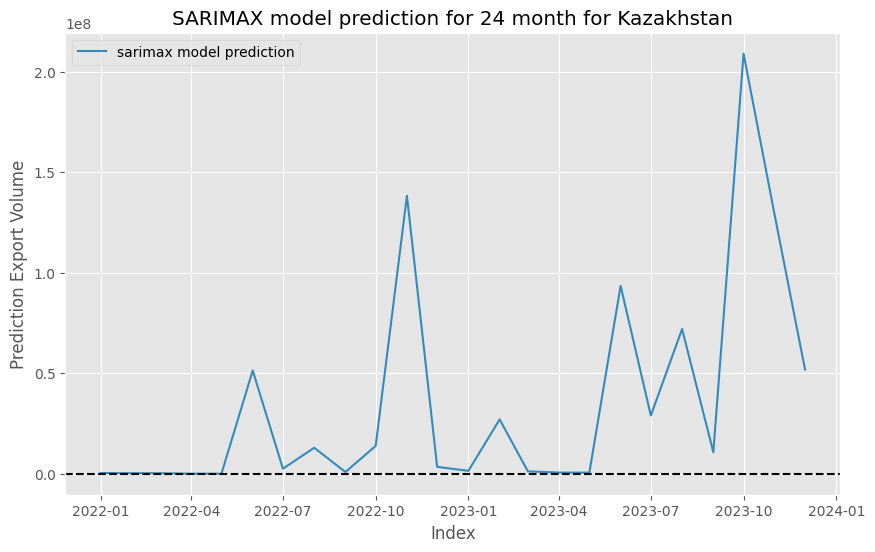

In [56]:
potash_log = np.log(df_potash_time['potash value'] + 1)

sarima_model = SARIMAX(endog=potash_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')
model_fit = sarima_model.fit(disp=False)

forecast = model_fit.get_forecast(steps=24)
sarima_predict = np.exp(forecast.predicted_mean)
sarima_predict.index = forecast.summary_frame().index

df_forecast = sarima_predict.to_frame(name='forecast')
df_forecast['index'] = index
df_forecast = df_forecast.set_index('index')

plt.figure(figsize=(10, 6))

sns.lineplot(x=df_forecast.index.to_timestamp(), y=df_forecast['forecast'], color='C1', label='sarimax model prediction')
plt.title('SARIMAX model prediction for 24 month for Kazakhstan')
plt.xlabel('Index')
plt.ylabel('Prediction Export Volume')
plt.axhline(y=df_potash_time['potash value'].mean(), ls='--', color='black')
plt.show()

Как мы видим, экспорт на протяжении времени возрастает или остается на том же уровне относительно среднего экспорта. Значит данный рынок является вполне перспективным.

Теперь перейдем к изучению шоков связанных с экзогенными переменными. Экзогенными переменными стали газ (основное топливо для заводов и в том числе по производству удобрений, важный товар который может отказать не маленькое влияние на остальные товары) и помидоры (культура, нуждающаяся в калийных удобрениях для роста, а так же скоропортящийся товар, что так же будет оказывать влияние на экспорт удобрений).

In [57]:
for col in df_comtarade.columns:
    p_value_adf = adfuller(df_comtarade[col], autolag='AIC', regression='c')[1]
    p_value_kpss = kpss(df_comtarade[col], regression='c')[1]

    if p_value_adf < 0.05 and p_value_kpss > 0.05:
        print(f'Ряд {col} - стационарен')
    else:
        print(f'Ряд {col} - не стационарен')

Ряд potash value - не стационарен
Ряд gas value - стационарен
Ряд tomato value - стационарен


Рассмотрим первые разности

In [58]:
df_comtarade_delta_1 = df_comtarade.copy().diff(1).dropna()
for col in df_comtarade_delta_1.columns:
    p_value_adf = adfuller(df_comtarade_delta_1[col], autolag='AIC', regression='c')[1]
    p_value_kpss = kpss(df_comtarade_delta_1[col], regression='c')[1]

    if p_value_adf < 0.05 and p_value_kpss > 0.05:
        print(f'Ряд {col} - стационарен')
    else:
        print(f'Ряд {col} - не стационарен')

Ряд potash value - стационарен
Ряд gas value - стационарен
Ряд tomato value - стационарен


Отлично, тут все стацонарно, значит продолжим работать с первыми разностями и проведем Granger Causality Test.

In [59]:
n = len(df_comtarade_delta_1.columns)

matrix = np.zeros((n, n))
df_results = pd.DataFrame(matrix, columns=df_comtarade_delta_1.columns, index=df_comtarade_delta_1.columns)

for y in df_comtarade_delta_1.columns:
    for x in df_comtarade_delta_1.columns:
        if x == y:
            continue
        grangercausalitytests_result = grangercausalitytests(x=df_comtarade_delta_1[[y, x]], maxlag=4)
        p_value = grangercausalitytests_result[4][0]['ssr_chi2test'][1] 
        df_results.loc[x, y] = p_value


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0201  , p=0.8873  , df_denom=440, df_num=1
ssr based chi2 test:   chi2=0.0202  , p=0.8869  , df=1
likelihood ratio test: chi2=0.0202  , p=0.8869  , df=1
parameter F test:         F=0.0201  , p=0.8873  , df_denom=440, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4483  , p=0.6390  , df_denom=437, df_num=2
ssr based chi2 test:   chi2=0.9068  , p=0.6355  , df=2
likelihood ratio test: chi2=0.9058  , p=0.6358  , df=2
parameter F test:         F=0.4483  , p=0.6390  , df_denom=437, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3166  , p=0.8133  , df_denom=434, df_num=3
ssr based chi2 test:   chi2=0.9653  , p=0.8097  , df=3
likelihood ratio test: chi2=0.9642  , p=0.8099  , df=3
parameter F test:         F=0.3166  , p=0.8133  , df_denom=434, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.2620  , p=0.9023  

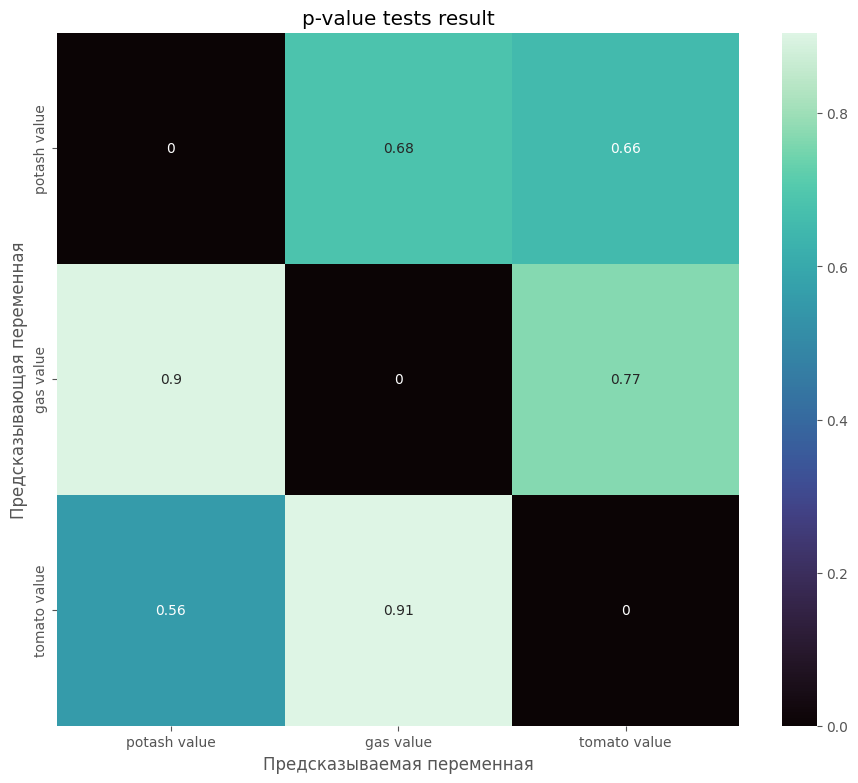

In [60]:
plt.figure(figsize=(11, 9))

sns.heatmap(data=df_results, annot=True, cmap='mako', fmt='.2g')
plt.title('p-value tests result')
plt.xlabel('Предсказываемая переменная')
plt.ylabel('Предсказывающая переменная')
plt.show()

Тест показал отсутствие стат-значимых зависимостей переменных, это говорит нам об отсутствии короткосрочных связей и больших лагах в шоках. 

Далее проведем тест Йохансена для стандартных рядов

In [61]:
johansen = coint_johansen(df_comtarade, k_ar_diff=3, det_order=0)

rank = 0
for i in range(len(johansen.lr1)):
    if johansen.lr1[i] > johansen.cvt[i, 1]:
        rank = rank + 1
    else:
        break
print(f'Ранг: {rank}')

# print(f'Trace statistic: \n{johansen.lr1}\n')
# print(f'Critical value trace: \n{johansen.cvt}\n')

# johansen_table = pd.DataFrame(index=["r=0", "r<=1", "r<=2"])
# johansen_table["trace_stat"] = johansen.lr1
# johansen_table["cv95"] = johansen.cvt[:, 1]
# johansen_table["reject?"] = johansen_table["trace_stat"] > johansen_table["cv95"]
# johansen_table.round(2)

Ранг: 3


Так как ранг модели 3 из 3, то выбираем обычную VAR модель для стандартных рядов, а не первых разностей.

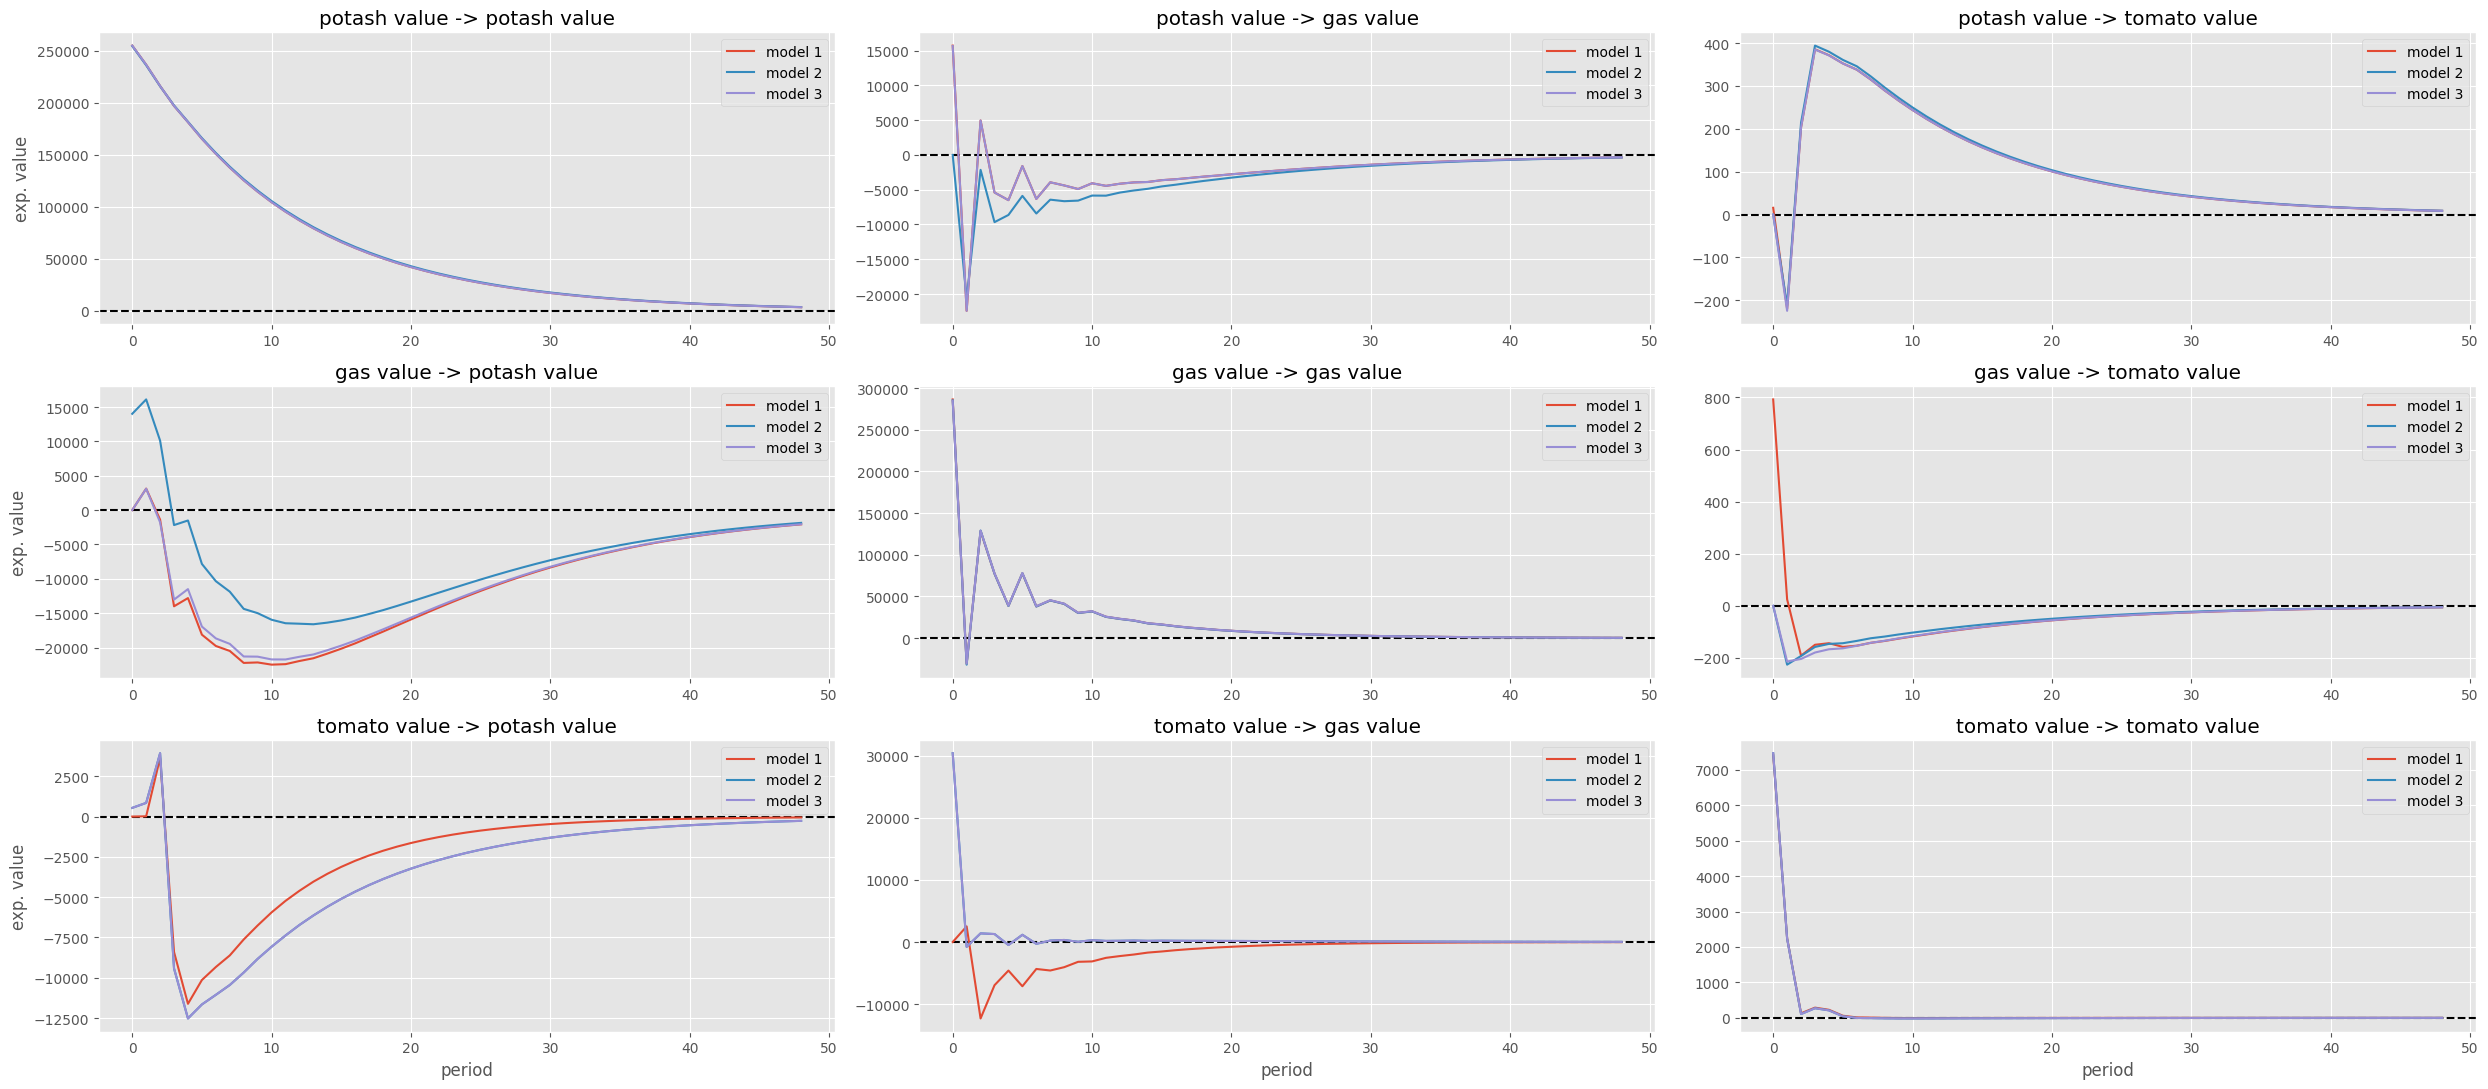

In [62]:
df_comtarade1 = df_comtarade.loc[:, ['potash value', 'gas value', 'tomato value']] 
df_comtarade2 = df_comtarade.loc[:, ['tomato value', 'gas value', 'potash value']] 
df_comtarade3 = df_comtarade.loc[:, ['tomato value', 'potash value', 'gas value']]

period = 48

model_var1 = VAR(endog=df_comtarade1)
res1 = model_var1.fit(3, ic='aic')
var_irf1 = res1.irf(periods=period) 

model_var2 = VAR(endog=df_comtarade2)
res2 = model_var2.fit(3, ic='aic')
var_irf2 = res2.irf(periods=period) 

model_var3 = VAR(endog=df_comtarade3)
res3 = model_var3.fit(3, ic='aic')
var_irf3 = res3.irf(periods=period) 


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 11))

for i, col1 in enumerate(df_comtarade1.columns):
    for j, col2 in enumerate(df_comtarade1.columns):

        ax = axes[i, j]

        ax.axhline(y=0, color='black', ls='--')

        idx_imp1 = df_comtarade1.columns.get_loc(col1)
        idx_res1 = df_comtarade1.columns.get_loc(col2)
        
        idx_imp2 = df_comtarade2.columns.get_loc(col1)
        idx_res2 = df_comtarade2.columns.get_loc(col2)

        idx_imp3= df_comtarade3.columns.get_loc(col1)
        idx_res3 = df_comtarade3.columns.get_loc(col2)

        line1 = var_irf1.orth_irfs[:, idx_res1, idx_imp1]

        line2 = var_irf2.orth_irfs[:, idx_res2, idx_imp2]

        line3 = var_irf3.orth_irfs[:, idx_res3, idx_imp3]
        
        sns.lineplot(data=line1, color='C0', label=f'model 1', ax=ax)
        sns.lineplot(data=line2, color='C1', label=f'model 2', ax=ax)
        sns.lineplot(data=line3, color='C2', label=f'model 3', ax=ax)
        
        ax.set_title(f'{col1} -> {col2}')
        ax.legend()
        if i == 2:
            ax.set_xlabel('period')
        if j == 0:
            ax.set_ylabel('exp. value')


plt.tight_layout() 
plt.show()

Построение IRF для разного порядка переменных на период 48 месяцев показывает их сходимость обратно к нулю, то есть за 4 года экспорт страны оправится от любого шока и прийдет в изначальное состояние без изменений. Это говорит нам об устойчивости экспорта калийных удобрений.